In [1]:
import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import PCA

In [2]:
INSTRUMENTS     = ['cl1s', 'ho1s', 'rb1s', 'ng1s']
UNSUP_TRAIN_END = '2019-12-31'
RANDOM_STATE    = 42
SP_WINDOW       = 64       # rolling window length for spectral features

In [3]:
ohlcv = pd.read_csv('ohlcv_data.csv')
ohlcv['date'] = pd.to_datetime(ohlcv['date'], format='%Y-%m-%d')
ohlcv = ohlcv.sort_values(['instrument', 'date']).reset_index(drop=True)

# split into one DataFrame per instrument (each has a different start date)
ohlcv_dict = {}
for inst in INSTRUMENTS:
    sub = ohlcv[ohlcv['instrument'] == inst].copy()
    sub = sub.set_index('date').sort_index()
    sub = sub[['open', 'high', 'low', 'close', 'volume', 'open_interest']]
    ohlcv_dict[inst] = sub

print('OHLCV loaded. Instrument shapes:')
for inst in INSTRUMENTS:
    print(' ', inst, ohlcv_dict[inst].shape, 'from', ohlcv_dict[inst].index.min().date(),
          'to', ohlcv_dict[inst].index.max().date())


OHLCV loaded. Instrument shapes:
  cl1s (8171, 6) from 1990-01-02 to 2022-06-30
  ho1s (8169, 6) from 1990-01-02 to 2022-06-30
  rb1s (8170, 6) from 1990-01-02 to 2022-06-30
  ng1s (8104, 6) from 1990-04-04 to 2022-06-30


In [4]:
returns_panel = pd.concat(
    [np.log(ohlcv_dict[i]['close']).diff().rename(i) for i in INSTRUMENTS], axis=1
)
vol_panel = pd.concat(
    [np.log(ohlcv_dict[i]['close']).diff().rolling(20).std().rename(i) for i in INSTRUMENTS],
    axis=1,
)

In [5]:
def feat_returns(df):
    """Log returns and simple transforms."""
    out = pd.DataFrame(index=df.index)
    log_close = np.log(df['close'])
    out['logret_1']   = log_close.diff()
    out['logret_abs'] = out['logret_1'].abs()
    out['logret_sq']  = out['logret_1'] ** 2
    return out


def feat_volatility(df, window=20):
    """Close-to-close vol, Parkinson vol, vol-of-vol."""
    out = pd.DataFrame(index=df.index)
    logret = np.log(df['close']).diff()
    out[f'vol_cc_{window}']   = logret.rolling(window).std()
    out[f'vov_{window}']      = out[f'vol_cc_{window}'].rolling(window).std()
    hl = np.log(df['high'] / df['low'])
    park_var = (hl ** 2) / (4.0 * np.log(2.0))
    out[f'vol_park_{window}'] = np.sqrt(park_var.rolling(window).mean())
    return out


def feat_range(df, window=14):
    """Intraday range and ATR (normalised by close)."""
    out = pd.DataFrame(index=df.index)
    out['range_norm'] = (df['high'] - df['low']) / df['close']
    prev_close = df['close'].shift(1)
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - prev_close).abs()
    tr3 = (df['low']  - prev_close).abs()
    tr  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    out[f'atr_{window}'] = tr.rolling(window).mean() / df['close']
    return out


def feat_volume(df, window=20):
    """Log-volume and rolling z-score."""
    out = pd.DataFrame(index=df.index)
    log_vol = np.log(df['volume'].clip(lower=1))
    mu = log_vol.rolling(window).mean()
    sd = log_vol.rolling(window).std()
    out['log_volume'] = log_vol
    out['vol_z']      = (log_vol - mu) / (sd + 1e-9)
    return out


def feat_open_interest(df, window=20):
    """OI z-score and signed OI change."""
    out = pd.DataFrame(index=df.index)
    log_oi = np.log(df['open_interest'].clip(lower=1))
    mu = log_oi.rolling(window).mean()
    sd = log_oi.rolling(window).std()
    out['oi_z']             = (log_oi - mu) / (sd + 1e-9)
    out['oi_signed_change'] = df['open_interest'].diff() * np.sign(df['close'].diff())
    return out

In [6]:
def feat_alphas(df):
    """
    Compute selected alphas from Kakushadze (2015) "101 Formulaic Alphas".
    Since VWAP is not in the data, we approximate it with the typical price
    (high + low + close) / 3, which is the standard proxy.
    Note: cross-sectional rank() is replaced with rolling time-series rank
    because this is a single-asset series.
    """
    out = pd.DataFrame(index=df.index)

    o, h, l, c, v = df['open'], df['high'], df['low'], df['close'], df['volume']
    vwap = (h + l + c) / 3.0                       # vwap proxy
    returns = c.pct_change()

    # helpers
    def ts_rank(x, d):
        return x.rolling(d).rank(pct=True)
    def signed_power(x, a):
        return np.sign(x) * (x.abs() ** a)
    def scale(x, a=1.0):
        return x * (a / (x.abs().rolling(20).sum() + 1e-12))

    # ---- Alpha#1: (rank(Ts_ArgMax(SignedPower(((returns<0)?stddev(returns,20):close),2),5))-0.5)
    cond = np.where(returns < 0, returns.rolling(20).std(), c)
    sp = pd.Series(cond, index=df.index) ** 2
    out['a1'] = ts_rank(sp.rolling(5).apply(np.argmax, raw=True), 5) - 0.5

    # ---- Alpha#6: (-1 * correlation(open, volume, 10))
    out['a6'] = -o.rolling(10).corr(v)

    # ---- Alpha#41: ((high * low)^0.5) - vwap
    out['a41'] = np.sqrt(h * l) - vwap

    # ---- Alpha#53: -1 * delta((((close - low) - (high - close)) / (close - low)), 9)
    inner = ((c - l) - (h - c)) / (c - l + 1e-9)
    out['a53'] = -(inner - inner.shift(9))

    # ---- Alpha#54: (-1 * ((low - close) * (open^5))) / ((low - high) * (close^5))
    out['a54'] = (-1 * ((l - c) * (o ** 5))) / ((l - h) * (c ** 5) + 1e-12)

    # ---- Alpha#84: SignedPower(Ts_Rank((vwap - ts_max(vwap, 15)), 21), delta(close, 5))
    x = vwap - vwap.rolling(15).max()
    out['a84'] = signed_power(ts_rank(x, 21), c.diff(5))

    # ---- Alpha#32: scale((sum(close,7)/7 - close)) + 20*scale(correlation(vwap, delay(close,5), 230))
    term1 = scale(c.rolling(7).mean() - c)
    term2 = 20 * scale(vwap.rolling(230).corr(c.shift(5)))
    out['a32'] = term1 + term2

    return out

In [7]:
def feat_cross_sectional(instrument, returns_panel, vol_panel):
    """Where this instrument sits relative to the rest of the complex."""
    out = pd.DataFrame(index=returns_panel.index)
    ret_ranks = returns_panel.rank(axis=1, pct=True)
    vol_ranks = vol_panel.rank(axis=1, pct=True)
    out['xs_ret_rank']       = ret_ranks[instrument]
    out['xs_vol_rank']       = vol_ranks[instrument]
    out['xs_dispersion']     = returns_panel.std(axis=1)
    composite                = returns_panel.mean(axis=1)
    out['xs_excess_ret']     = returns_panel[instrument] - composite
    out['xs_corr_composite'] = returns_panel[instrument].rolling(60).corr(composite)
    return out

In [8]:
def _dft_matrix(N):
    n = np.arange(N)
    k = n[:, None]
    return np.exp(-2j * np.pi * k * n / N) / np.sqrt(N)


def _dfrft_matrix(N, alpha):
    F = _dft_matrix(N)
    eigvals, eigvecs = np.linalg.eig(F)
    inv_eigvecs = np.linalg.inv(eigvecs)
    frac = alpha / (np.pi / 2)
    return eigvecs @ np.diag(eigvals ** frac) @ inv_eigvecs


def dfrft(x, alpha, matrix=None):
    """
    Discrete Fractional Fourier Transform via fractional power of the unitary DFT matrix.
    alpha = 0 -> identity, alpha = pi/2 -> standard FFT.
    """
    N = len(x)
    a_mod = alpha % np.pi
    if np.isclose(a_mod, 0):
        return x.astype(complex)
    if np.isclose(a_mod, np.pi / 2):
        return np.fft.fft(x) / np.sqrt(N)
    if matrix is not None:
        return matrix @ x.astype(complex)
    return _dfrft_matrix(N, alpha) @ x.astype(complex)


def hilbert_transform(x):
    """Analytic signal via FFT (multiply positive freqs by 2, kill negatives)."""
    N = len(x)
    X = np.fft.fft(x)
    H = np.zeros(N, dtype=complex)
    if N % 2 == 0:
        H[0]      = X[0]
        H[N // 2] = X[N // 2]
        H[1:N // 2] = 2 * X[1:N // 2]
    else:
        H[0] = X[0]
        H[1:(N + 1) // 2] = 2 * X[1:(N + 1) // 2]
    return np.fft.ifft(H)


def ssa_singular_values(x):
    """Singular Spectrum Analysis: SVD of the trajectory (Hankel) matrix."""
    N = len(x)
    L = N // 2
    K = N - L + 1
    H = np.zeros((L, K))
    for i in range(L):
        H[i] = x[i:i + K]
    s = np.linalg.svd(H, compute_uv=False)
    return s


def feat_signal_processing(df, window=SP_WINDOW):
    """
    Rolling spectral features on log-returns.
    Per window we extract:
      - DFrFT at alpha = pi/4: low-band E, high-band E, spectral entropy, centroid
      - S-transform proxy (FFT in low/mid/high bands + entropy)
      - Hilbert analytic signal: mean/std of amplitude and instantaneous frequency
      - SSA: trend / cycle / noise energy fractions
    """
    logret = np.log(df['close']).diff().fillna(0.0).values
    n = len(logret)

    # output buffers
    dfrft_low      = np.full(n, np.nan)
    dfrft_high     = np.full(n, np.nan)
    dfrft_entropy  = np.full(n, np.nan)
    dfrft_centroid = np.full(n, np.nan)
    dfrft_alpha_star    = np.full(n, np.nan)   # NEW: optimal alpha
    dfrft_entropy_star  = np.full(n, np.nan)   # NEW: entropy at the optimum

    s_low     = np.full(n, np.nan)
    s_mid     = np.full(n, np.nan)
    s_high    = np.full(n, np.nan)
    s_entropy = np.full(n, np.nan)

    h_amp_mean  = np.full(n, np.nan)
    h_amp_std   = np.full(n, np.nan)
    h_freq_mean = np.full(n, np.nan)
    h_freq_std  = np.full(n, np.nan)

    ssa_trend = np.full(n, np.nan)
    ssa_cycle = np.full(n, np.nan)
    ssa_noise = np.full(n, np.nan)

    alpha_val = 0.5 * np.pi / 2   # half-rotation - between time and frequency
    alpha_grid = np.arange(0.05, 1.0, 0.1) * (np.pi / 2)
    alpha_list = np.concatenate([alpha_grid, [alpha_val]])
    dfrft_matrices = {a: _dfrft_matrix(window, a) for a in alpha_list}
    L4 = window // 4
    L3 = window // 3
    freqs = np.arange(window)

    for t in range(window - 1, n):
        x = logret[t - window + 1 : t + 1]

        # --- DFrFT ---
        entropies  = np.zeros(len(alpha_grid))

        for i, a in enumerate(alpha_grid):
            Y_a   = dfrft_matrices[a] @ x
            mag_a = np.abs(Y_a) ** 2
            p_a   = mag_a / (mag_a.sum() + 1e-12)
            entropies[i] = -(p_a * np.log(p_a + 1e-12)).sum()

        # alpha* = the alpha that minimises entropy (most concentrated transform)
        star_idx = int(np.argmin(entropies))
        dfrft_alpha_star[t]   = alpha_grid[star_idx] / (np.pi / 2)   # normalise to [0,1]
        dfrft_entropy_star[t] = entropies[star_idx]

        # keep the 4 "default" features at alpha = pi/4 for consistency
        Y     = dfrft_matrices[alpha_val] @ x
        mag   = np.abs(Y) ** 2
        total = mag.sum() + 1e-12
        p     = mag / total
        dfrft_low[t]      = mag[:L4].sum() / total
        dfrft_high[t]     = mag[-L4:].sum() / total
        dfrft_entropy[t]  = -(p * np.log(p + 1e-12)).sum()
        dfrft_centroid[t] = (freqs * p).sum()

        # --- S-transform proxy (FFT energy in 3 bands + entropy) ---
        X     = np.fft.fft(x)
        pwr   = np.abs(X) ** 2
        total = pwr.sum() + 1e-12
        p     = pwr / total
        s_low[t]     = pwr[:L3].sum() / total
        s_mid[t]     = pwr[L3:2 * L3].sum() / total
        s_high[t]    = pwr[2 * L3:].sum() / total
        s_entropy[t] = -(p * np.log(p + 1e-12)).sum()

        # --- Hilbert ---
        analytic = hilbert_transform(x)
        amp      = np.abs(analytic)
        phase    = np.unwrap(np.angle(analytic))
        ifreq    = np.diff(phase) / (2 * np.pi)
        h_amp_mean[t]  = amp.mean()
        h_amp_std[t]   = amp.std()
        h_freq_mean[t] = ifreq.mean()
        h_freq_std[t]  = ifreq.std()

        # --- SSA ---
        s     = ssa_singular_values(x)
        s2    = s ** 2
        total = s2.sum() + 1e-12
        ssa_trend[t] = s2[0] / total
        ssa_cycle[t] = s2[1:3].sum() / total
        ssa_noise[t] = s2[3:].sum() / total

    out = pd.DataFrame(index=df.index)
    out['dfrft_low']      = dfrft_low
    out['dfrft_high']     = dfrft_high
    out['dfrft_entropy']  = dfrft_entropy
    out['dfrft_centroid'] = dfrft_centroid
    out['dfrft_alpha_star']   = dfrft_alpha_star
    out['dfrft_entropy_star'] = dfrft_entropy_star
    out['s_low']          = s_low
    out['s_mid']          = s_mid
    out['s_high']         = s_high
    out['s_entropy']      = s_entropy
    out['h_amp_mean']     = h_amp_mean
    out['h_amp_std']      = h_amp_std
    out['h_freq_mean']    = h_freq_mean
    out['h_freq_std']     = h_freq_std
    out['ssa_trend']      = ssa_trend
    out['ssa_cycle']      = ssa_cycle
    out['ssa_noise']      = ssa_noise
    return out

In [9]:
def fit_gmm(X_train, n_components=3, random_state=RANDOM_STATE):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    gmm = GaussianMixture(
        n_components=n_components, covariance_type='full',
        n_init=5, max_iter=200, random_state=random_state,
    )
    gmm.fit(X_train_scaled)
    return scaler, gmm


def gmm_features(X, scaler, gmm):
    X_scaled = scaler.transform(X)
    probs = gmm.predict_proba(X_scaled)
    cols = ['gmm_p' + str(k) for k in range(gmm.n_components)]
    return pd.DataFrame(probs, index=X.index, columns=cols)

In [10]:
def fit_hmm(X_train, n_states=3, random_state=RANDOM_STATE):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    hmm = GaussianHMM(
        n_components=n_states, covariance_type='full',
        n_iter=200, random_state=random_state,
    )
    hmm.fit(X_train_scaled)
    return scaler, hmm


def hmm_forward_filter(X, scaler, hmm):
    X_scaled = scaler.transform(X)
    n_obs = X_scaled.shape[0]
    K = hmm.n_components

    emission = np.zeros((n_obs, K))
    for k in range(K):
        emission[:, k] = multivariate_normal.pdf(
            X_scaled, mean=hmm.means_[k], cov=hmm.covars_[k], allow_singular=True
        )
    emission = np.clip(emission, 1e-300, None)

    def logsumexp(a, axis=None):
        a = np.asarray(a)
        max_a = np.max(a, axis=axis, keepdims=True)
        return np.squeeze(max_a + np.log(np.sum(np.exp(a - max_a), axis=axis, keepdims=True)), axis=axis)

    log_emission = np.log(emission)
    log_pi = np.log(hmm.startprob_ + 1e-300)
    log_A = np.log(hmm.transmat_ + 1e-300)

    log_alpha = np.zeros((n_obs, K))
    log_alpha[0] = log_pi + log_emission[0]
    for t in range(1, n_obs):
        s = log_alpha[t - 1][:, None] + log_A
        log_alpha[t] = logsumexp(s, axis=0) + log_emission[t]

    log_norm = logsumexp(log_alpha, axis=1)
    alpha = np.exp(log_alpha - log_norm[:, None])

    cols = ['hmm_p' + str(k) for k in range(K)]
    return pd.DataFrame(alpha, index=X.index, columns=cols)


In [11]:
def fit_kmeans(X_train, n_clusters=4, random_state=RANDOM_STATE):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    km.fit(X_train_scaled)
    return scaler, km


def kmeans_features(X, scaler, km):
    X_scaled = scaler.transform(X)
    distances = km.transform(X_scaled)
    cols = ['km_dist_' + str(k) for k in range(km.n_clusters)]
    return pd.DataFrame(distances, index=X.index, columns=cols)

In [12]:
def build_return_windows(df, window=SP_WINDOW):
    """
    Build a matrix where each row t is the last `window` log returns ending at t.
    The first window-1 rows are NaN (window not yet full).
    """
    logret = np.log(df['close']).diff().fillna(0.0).values
    n = len(logret)
    W = np.full((n, window), np.nan)
    for t in range(window - 1, n):
        W[t] = logret[t - window + 1 : t + 1]
    return pd.DataFrame(W, index=df.index)


def fit_pca(W_train, n_components=3, random_state=RANDOM_STATE):
    """Fit PCA on a matrix of training windows."""
    scaler = StandardScaler()
    W_train_scaled = scaler.fit_transform(W_train)
    pca = PCA(n_components=n_components, random_state=random_state)
    pca.fit(W_train_scaled)
    return scaler, pca


def pca_features(W, scaler, pca):
    """
    Project each window onto the top PCs and compute reconstruction error.
    Returns n_components + 1 columns.
    """
    W_scaled = scaler.transform(W)
    proj     = pca.transform(W_scaled)
    recon    = pca.inverse_transform(proj)
    err      = np.sqrt(((W_scaled - recon) ** 2).sum(axis=1))
    cols_pc  = ['pca_pc' + str(i) for i in range(pca.n_components_)]
    out      = pd.DataFrame(proj, index=W.index, columns=cols_pc)
    out['pca_recon_err'] = err
    return out

In [13]:

# ── Fast path: load pre-computed features from saved CSV files ────────────────
# This cell replaces the slow rolling feature-engineering loop.
# Run this cell and SKIP the next cell (the full feature engineering loop).
features_dict = {}
for inst in INSTRUMENTS:
    df = pd.read_csv(
        f'features_{inst}.csv',
        parse_dates=['date'],
        index_col='date',
    )
    df.index = pd.to_datetime(df.index)
    df.index.name = 'date'
    features_dict[inst] = df

print("Features loaded from saved CSV files:")
for inst, df in features_dict.items():
    print(f"  {inst}: {df.shape}  "
          f"from {df.index.min().date()} to {df.index.max().date()}")


Features loaded from saved CSV files:
  cl1s: (8171, 56)  from 1990-01-02 to 2022-06-30
  ho1s: (8169, 56)  from 1990-01-02 to 2022-06-30
  rb1s: (8170, 56)  from 1990-01-02 to 2022-06-30
  ng1s: (8104, 56)  from 1990-04-04 to 2022-06-30


In [13]:
features_dict = {}

for inst in INSTRUMENTS:
    print('\nBuilding features for', inst, '...')
    df = ohlcv_dict[inst]

    # ---- F1 + F2 : stateless per-instrument features ----
    base = pd.concat([
        feat_returns(df),
        feat_volatility(df, window=20),
        feat_range(df, window=14),
        feat_volume(df, window=20),
        feat_open_interest(df, window=20),
        feat_alphas(df),
    ], axis=1)

    # ---- F3 : cross-sectional ----
    xs = feat_cross_sectional(inst, returns_panel, vol_panel).reindex(base.index)

    # ---- F4 : signal-processing features (rolling, slow) ----
    print('  - signal processing (rolling window =', SP_WINDOW, ')')
    sp = feat_signal_processing(df, window=SP_WINDOW)

    # ---- input vector for GMM / HMM / KMeans ----
    unsup_input = base[['logret_1', 'vol_cc_20', 'range_norm', 'vol_z', 'oi_z']].copy()
    train_mask  = (unsup_input.index <= UNSUP_TRAIN_END) & unsup_input.notna().all(axis=1)
    score_mask  = unsup_input.notna().all(axis=1)
    X_train     = unsup_input.loc[train_mask].values
    X_score     = unsup_input.loc[score_mask]

    # ---- F5 : GMM ----
    print('  - GMM')
    gmm_scaler, gmm = fit_gmm(X_train, n_components=3)
    gmm_df = gmm_features(X_score, gmm_scaler, gmm).reindex(base.index)

    # ---- F6 : HMM with forward filtering ----
    print('  - HMM (forward filter)')
    hmm_scaler, hmm = fit_hmm(X_train, n_states=3)
    hmm_df = hmm_forward_filter(X_score, hmm_scaler, hmm).reindex(base.index)

    # ---- F7 : KMeans ----
    print('  - KMeans')
    km_scaler, km = fit_kmeans(X_train, n_clusters=4)
    km_df = kmeans_features(X_score, km_scaler, km).reindex(base.index)

    # ---- F8 : PCA on rolling return windows ----
    print('  - PCA on rolling return windows')
    W_full          = build_return_windows(df, window=SP_WINDOW)
    train_mask_pca  = (W_full.index <= UNSUP_TRAIN_END) & W_full.notna().all(axis=1)
    score_mask_pca  = W_full.notna().all(axis=1)
    W_train         = W_full.loc[train_mask_pca].values
    W_score         = W_full.loc[score_mask_pca]
    pca_scaler, pca = fit_pca(W_train, n_components=3)
    pca_df          = pca_features(W_score, pca_scaler, pca).reindex(base.index)

    # ---- combine ----
    all_features = pd.concat([base, xs, sp, gmm_df, hmm_df, km_df, pca_df], axis=1)
    all_features['instrument'] = inst
    all_features.index.name = 'date'
    features_dict[inst] = all_features


Building features for cl1s ...
  - signal processing (rolling window = 64 )
  - GMM


/workspaces/Systematic_Trading_Strategy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  - HMM (forward filter)


/workspaces/Systematic_Trading_Strategy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  - KMeans
  - PCA on rolling return windows

Building features for ho1s ...
  - signal processing (rolling window = 64 )


...

  - GMM


/workspaces/Systematic_Trading_Strategy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  - HMM (forward filter)


/workspaces/Systematic_Trading_Strategy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/workspaces/Systematic_Trading_Strategy/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  - KMeans
  - PCA on rolling return windows


In [14]:
for inst, df_feat in features_dict.items():
    print('\n' + inst, ':', df_feat.shape)
    print('Columns:', list(df_feat.columns))
    print(df_feat.tail(3))


cl1s : (8171, 56)
Columns: ['logret_1', 'logret_abs', 'logret_sq', 'vol_cc_20', 'vov_20', 'vol_park_20', 'range_norm', 'atr_14', 'log_volume', 'vol_z', 'oi_z', 'oi_signed_change', 'a1', 'a6', 'a41', 'a53', 'a54', 'a84', 'a32', 'xs_ret_rank', 'xs_vol_rank', 'xs_dispersion', 'xs_excess_ret', 'xs_corr_composite', 'dfrft_low', 'dfrft_high', 'dfrft_entropy', 'dfrft_centroid', 'dfrft_alpha_star', 'dfrft_entropy_star', 's_low', 's_mid', 's_high', 's_entropy', 'h_amp_mean', 'h_amp_std', 'h_freq_mean', 'h_freq_std', 'ssa_trend', 'ssa_cycle', 'ssa_noise', 'gmm_p0', 'gmm_p1', 'gmm_p2', 'hmm_p0', 'hmm_p1', 'hmm_p2', 'km_dist_0', 'km_dist_1', 'km_dist_2', 'km_dist_3', 'pca_pc0', 'pca_pc1', 'pca_pc2', 'pca_recon_err', 'instrument']
            logret_1  logret_abs  logret_sq  vol_cc_20    vov_20  vol_park_20  \
date                                                                            
2022-06-28  0.019790    0.019790   0.000392   0.022935  0.004800     0.028291   
2022-06-29 -0.017875    0.01

In [15]:
for inst, df in features_dict.items():
    df.to_csv(f'features_{inst}.csv')

# Labeling (Triple-Barrier Method)

In [14]:
# Filter energy instruments only 
ohlcv_energy = (
    ohlcv[ohlcv['instrument'].isin(INSTRUMENTS)]
    .sort_values(['instrument', 'date'])
    .reset_index(drop=True)
)

In [15]:
# Load signal data
signals = pd.read_csv('primary_signals.csv')
signals['date'] = pd.to_datetime(signals['date'], format='%Y-%m-%d')

# Reshape signals from wide to long format
signals_long = (
    signals[['date'] + INSTRUMENTS]
    .melt(id_vars='date',
          var_name='instrument',
          value_name='signal')
    .sort_values(['instrument', 'date'])
    .reset_index(drop=True)
)

# Merge signals onto OHLCV
df = ohlcv_energy.merge(signals_long, on=['date', 'instrument'], how='left')
df

,date,instrument,open,high,low,close,volume,open_interest,signal
0,1990-01-02,cl1s,21.800000,22.920000,21.790000,22.890000,22868.000000,66308.000000,NaN
1,1990-01-03,cl1s,23.200000,23.800000,23.000000,23.680000,45177.000000,61428.000000,NaN
2,1990-01-04,cl1s,23.880000,23.920000,22.830000,23.410000,50061.000000,60995.000000,NaN
3,1990-01-05,cl1s,23.420000,23.700000,23.030000,23.080000,53070.000000,57258.000000,NaN
4,1990-01-08,cl1s,22.600000,22.600000,21.550000,21.620000,39720.000000,54644.000000,NaN
...,...,...,...,...,...,...,...,...,...
32609,2022-06-24,rb1s,10.685884,11.126945,10.645361,11.104921,19063.581086,29992.958924,1.0
32610,2022-06-27,rb1s,11.073207,11.243817,10.909057,10.982176,22195.552419,31771.613515,1.0
32611,2022-06-28,rb1s,11.062048,11.305483,10.851209,11.288452,22035.156801,32420.006841,-1.0
32612,2022-06-29,rb1s,11.137223,11.355991,10.732281,10.933430,24420.658507,31721.553736,-1.0


## Chooose Triple Barrier Parameters

In [18]:
import itertools

# ── Sensitivity analysis for all energy instruments ───────────
K_range          = [1.0, 1.5, 2.0]
T_range          = [10, 15, 20]
VOL_WINDOW_range = [10, 20, 30]

results = []

for inst in INSTRUMENTS:
    for vol_window, k, t in itertools.product(VOL_WINDOW_range, K_range, T_range):
        tmp = (df[df['instrument'] == inst]
               .copy()
               .sort_values('date')
               .reset_index(drop=True))
        tmp['ret'] = tmp['close'].pct_change()
        tmp['vol'] = tmp['ret'].rolling(vol_window).std()
        tmp = tmp.dropna().reset_index(drop=True)
        
        tmp['label'] = np.nan
        signal_rows = tmp[tmp['signal'].notna() & (tmp['signal'] != 0)].index

        for i in signal_rows:
            sig      = tmp.loc[i, 'signal']
            t0_price = tmp.loc[i, 'close']
            vol_est  = tmp.loc[i, 'vol']
            if pd.isna(vol_est) or vol_est == 0:
                continue
            upper  = t0_price * (1 + k * vol_est)
            lower  = t0_price * (1 - k * vol_est)
            future = tmp.loc[i+1 : i+t].reset_index(drop=True)
            if future.empty:
                continue
            label = 0
            for _, row in future.iterrows():
                if sig == 1:
                    if row['high'] >= upper:
                        label = 1; break
                    elif row['low'] <= lower:
                        label = -1; break
                elif sig == -1:
                    if row['low'] <= lower:
                        label = 1; break
                    elif row['high'] >= upper:
                        label = -1; break
            tmp.loc[i, 'label'] = label

        labelled = tmp[tmp['label'].notna()]
        total    = len(labelled)
        if total == 0:
            continue
        profit  = (labelled['label'] == 1).sum()
        timeout = (labelled['label'] == 0).sum()
        loss    = (labelled['label'] == -1).sum()

        results.append({
            'Instrument' : inst,
            'VOL_WINDOW' : vol_window,
            'K'          : k,
            'T'          : t,
            'Total'      : total,
            'Profit %'   : round(profit  / total * 100, 1),
            'Timeout %'  : round(timeout / total * 100, 1),
            'Loss %'     : round(loss    / total * 100, 1),
        })

results_df = pd.DataFrame(results)

# ── Print by instrument ───────────────────────────────────────
for inst in INSTRUMENTS:
    print(f"\n=== {inst.upper()} ===")
    print(results_df[results_df['Instrument'] == inst]
          .drop(columns='Instrument')
          .to_string(index=False))


=== CL1S ===
 VOL_WINDOW   K  T  Total  Profit %  Timeout %  Loss %
         10 1.0 10    421      58.9        0.0    41.1
         10 1.0 15    421      58.9        0.0    41.1
         10 1.0 20    421      58.9        0.0    41.1
         10 1.5 10    421      57.7        3.3    39.0
         10 1.5 15    421      59.6        0.5    39.9
         10 1.5 20    421      59.6        0.5    39.9
         10 2.0 10    421      56.1       10.9    33.0
         10 2.0 15    421      60.6        4.3    35.2
         10 2.0 20    421      61.5        2.4    36.1
         20 1.0 10    421      59.9        0.0    40.1
         20 1.0 15    421      59.9        0.0    40.1
         20 1.0 20    421      59.9        0.0    40.1
         20 1.5 10    421      58.0        3.1    39.0
         20 1.5 15    421      60.3        0.2    39.4
         20 1.5 20    421      60.3        0.2    39.4
         20 2.0 10    421      56.3       10.7    33.0
         20 2.0 15    421      60.8        4.0    3

In [16]:
# ── Triple Barrier Parameters ─────────────────────────────────
# Uniform parameters applied across all energy instruments.
# Energy commodities share common macro drivers (oil price cycles, geopolitical risk, supply/demand reports).
# Parameters selected based on sensitivity analysis across 27 possible combinations:
# K=2.0 rejected: Timeout % consistently >10% across all instruments
# T=10  rejected: elevated Timeout % for K≥1.5; T=15 and T=20 near-identical, T=15 preferred
# VOL_WINDOW=20 selected: industry standard (~1 trading month); results insensitive to this choice
# K=1.5 selected: Timeout ≈ 0% while maintaining meaningful barrier width
VOL_WINDOW = 20   # Volatility estimation lookback (~1 trading month)
K          = 1.5  # Barrier width in units of volatility
T          = 15   # Time barrier (~3 trading weeks)

## Apply Triple Barrier Labelling

In [17]:
def apply_triple_barrier(df_inst, vol_window, k, t):
    """
    Apply triple barrier labelling to a single instrument.

    Parameters
    ----------
    df_inst    : DataFrame for one instrument, sorted by date, NaNs dropped
    vol_window : Volatility estimation lookback (trading days)
    k          : Barrier width multiplier (units of volatility)
    t          : Time barrier (trading days)

    Returns
    -------
    df_inst with two new columns: label (-1, 0, 1) and t_hit (date)
    """
    df_inst = df_inst.copy()
    df_inst['ret'] = df_inst['close'].pct_change()
    df_inst['vol'] = df_inst['ret'].rolling(vol_window).std()
    df_inst = df_inst.dropna().reset_index(drop=True)

    df_inst['label'] = np.nan
    df_inst['t_hit']  = pd.NaT

    signal_rows = df_inst[df_inst['signal'].notna() & (df_inst['signal'] != 0)].index

    for i in signal_rows:
        sig      = df_inst.loc[i, 'signal']
        t0_price = df_inst.loc[i, 'close']
        vol_est  = df_inst.loc[i, 'vol']

        if pd.isna(vol_est) or vol_est == 0:
            continue

        upper  = t0_price * (1 + k * vol_est)
        lower  = t0_price * (1 - k * vol_est)
        future = df_inst.loc[i+1 : i+t].reset_index(drop=True)

        if future.empty:
            continue

        label = 0
        t_hit = future['date'].iloc[-1]

        for _, row in future.iterrows():
            if sig == 1:
                if row['high'] >= upper:
                    label = 1;  t_hit = row['date']; break   # profit-taking
                elif row['low'] <= lower:
                    label = -1; t_hit = row['date']; break   # stop-loss
            elif sig == -1:
                if row['low'] <= lower:
                    label = 1;  t_hit = row['date']; break   # profit-taking
                elif row['high'] >= upper:
                    label = -1; t_hit = row['date']; break   # stop-loss

        df_inst.loc[i, 'label'] = label
        df_inst.loc[i, 't_hit'] = t_hit

    return df_inst

In [18]:
# CL1S- WTI Crude Oil
df_cl = df[df['instrument'] == 'cl1s'].copy().sort_values('date').reset_index(drop=True)
cl = apply_triple_barrier(df_cl, VOL_WINDOW, K, T)
labelled_cl = cl[cl['label'].notna()]
total = len(labelled_cl)

print(f"Total labelled : {total}")
print(f"Label= 1 (profit) : {int((labelled_cl['label']== 1).sum())}"
      f"({(labelled_cl['label']== 1).mean()*100:.1f}%)")
print(f"Label= 0 (timeout) : {int((labelled_cl['label']== 0).sum())}"
      f"({(labelled_cl['label']== 0).mean()*100:.1f}%)")
print(f"Label= -1 (loss) : {int((labelled_cl['label']==-1).sum())}"
      f"({(labelled_cl['label']== -1).mean()*100:.1f}%)")
print(f"\nBy signal direction:")
print(labelled_cl.groupby(['signal','label']).size().unstack(fill_value=0))

Total labelled : 421
Label= 1 (profit) : 254(60.3%)
Label= 0 (timeout) : 1(0.2%)
Label= -1 (loss) : 166(39.4%)

By signal direction:
label   -1.0   0.0   1.0
signal                  
-1.0      11     0    25
 1.0     155     1   229


In [19]:
# HO1S - Heating Oil
df_ho = df[df['instrument'] == 'ho1s'].copy().sort_values('date').reset_index(drop=True)
ho = apply_triple_barrier(df_ho, VOL_WINDOW, K, T)
labelled_ho = ho[ho['label'].notna()]
total = len(labelled_ho)

print(f"Total labelled : {total}")
print(f"Label= 1 (profit) : {int((labelled_ho['label']== 1).sum())}"
      f"({(labelled_ho['label']== 1).mean()*100:.1f}%)")
print(f"Label= 0 (timeout) : {int((labelled_ho['label']== 0).sum())}"
      f"({(labelled_ho['label']== 0).mean()*100:.1f}%)")
print(f"Label= -1 (loss) : {int((labelled_ho['label']==-1).sum())}"
      f"({(labelled_ho['label']== -1).mean()*100:.1f}%)")
print(f"\nBy signal direction:")
print(labelled_ho.groupby(['signal','label']).size().unstack(fill_value=0))

Total labelled : 63
Label= 1 (profit) : 40(63.5%)
Label= 0 (timeout) : 0(0.0%)
Label= -1 (loss) : 23(36.5%)

By signal direction:
label   -1.0   1.0
signal            
-1.0       5     5
 1.0      18    35


In [20]:
# RB1S - RBOB Gasoline
df_rb = df[df['instrument'] == 'rb1s'].copy().sort_values('date').reset_index(drop=True)
rb = apply_triple_barrier(df_rb, VOL_WINDOW, K, T)
labelled_rb = rb[rb['label'].notna()]
total = len(labelled_rb)

print(f"Total labelled : {total}")
print(f"Label= 1 (profit) : {int((labelled_rb['label']== 1).sum())}"
      f"({(labelled_rb['label']== 1).mean()*100:.1f}%)")
print(f"Label= 0 (timeout) : {int((labelled_rb['label']== 0).sum())}"
      f"({(labelled_rb['label']== 0).mean()*100:.1f}%)")
print(f"Label= -1 (loss) : {int((labelled_rb['label']==-1).sum())}"
      f"({(labelled_rb['label']== -1).mean()*100:.1f}%)")
print(f"\nBy signal direction:")
print(labelled_rb.groupby(['signal','label']).size().unstack(fill_value=0))

Total labelled : 627
Label= 1 (profit) : 325(51.8%)
Label= 0 (timeout) : 1(0.2%)
Label= -1 (loss) : 301(48.0%)

By signal direction:
label   -1.0   0.0   1.0
signal                  
-1.0     146     0   115
 1.0     155     1   210


In [21]:
# NG1S - Natural Gas
df_ng = df[df['instrument'] == 'ng1s'].copy().sort_values('date').reset_index(drop=True)
ng = apply_triple_barrier(df_ng, VOL_WINDOW, K, T)
labelled_ng = ng[ng['label'].notna()]
total = len(labelled_ng)

print(f"Total labelled : {total}")
print(f"Label= 1 (profit) : {int((labelled_ng['label']== 1).sum())}"
      f"({(labelled_ng['label']== 1).mean()*100:.1f}%)")
print(f"Label= 0 (timeout) : {int((labelled_ng['label']== 0).sum())}"
      f"({(labelled_ng['label']== 0).mean()*100:.1f}%)")
print(f"Label= -1 (loss) : {int((labelled_ng['label']==-1).sum())}"
      f"({(labelled_ng['label']== -1).mean()*100:.1f}%)")
print(f"\nBy signal direction:")
print(labelled_ng.groupby(['signal','label']).size().unstack(fill_value=0))

Total labelled : 124
Label= 1 (profit) : 61(49.2%)
Label= 0 (timeout) : 0(0.0%)
Label= -1 (loss) : 63(50.8%)

By signal direction:
label   -1.0   1.0
signal            
-1.0      63    61


## Prepare Final Dataset for Model Training

In [22]:
# ── Merge all four instruments into one dataset ───────────────
df_labelled = pd.concat([labelled_cl, labelled_ho, labelled_rb, labelled_ng])
df_labelled = (df_labelled
               .sort_values(['instrument', 'date'])
               .reset_index(drop=True))
               
df_labelled

,date,instrument,open,high,low,close,volume,open_interest,signal,ret,vol,label,t_hit
0,2020-01-07,cl1s,25.496729,25.593998,25.172498,25.411618,1.437614e+06,8.772802e+05,-1.0,-0.009009,0.009824,1.0,2020-01-08
1,2020-01-22,cl1s,23.599977,23.648586,22.696648,22.984255,1.530855e+06,1.194576e+06,-1.0,-0.028092,0.016064,1.0,2020-01-23
2,2020-01-23,cl1s,22.729054,22.793867,22.186246,22.518412,1.737915e+06,1.183091e+06,-1.0,-0.020268,0.016475,1.0,2020-01-24
3,2020-01-24,cl1s,22.558920,22.664241,21.813573,21.951300,1.447108e+06,1.203433e+06,-1.0,-0.025184,0.016774,1.0,2020-01-27
4,2020-01-27,cl1s,21.752811,21.756861,21.116834,21.525966,1.759849e+06,1.191300e+06,-1.0,-0.019376,0.016632,1.0,2020-01-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1230,2022-06-23,rb1s,10.896724,11.066453,10.609242,10.750487,2.210224e+04,2.887428e+04,1.0,-0.018446,0.022345,1.0,2022-06-24
1231,2022-06-24,rb1s,10.685884,11.126945,10.645361,11.104921,1.906358e+04,2.999296e+04,1.0,0.032969,0.023391,-1.0,2022-06-30
1232,2022-06-27,rb1s,11.073207,11.243817,10.909057,10.982176,2.219555e+04,3.177161e+04,1.0,-0.011053,0.023272,-1.0,2022-06-30
1233,2022-06-28,rb1s,11.062048,11.305483,10.851209,11.288452,2.203516e+04,3.242001e+04,-1.0,0.027888,0.023035,1.0,2022-06-29


In [23]:
# ── Convert to binary label ───────────────────────────────────
# 1  (profit)  → 1  (signal is worth following)
# 0  (timeout) → 0  (signal is not worth following)
# -1 (loss)    → 0  (signal is not worth following)
df_labelled['label_binary'] = (df_labelled['label'] == 1).astype(int)

print(f"\nBinary label distribution:")
print(df_labelled.groupby(['instrument', 'label_binary']).size().unstack(fill_value=0))


Binary label distribution:
label_binary    0    1
instrument            
cl1s          167  254
ho1s           23   40
ng1s           63   61
rb1s          302  325


In [24]:
# ── Merge labels with features ────────────────────────────────
df_final = {}
for inst in INSTRUMENTS:
    label_cols = ['signal', 'label', 'label_binary', 't_hit']
    labels = (df_labelled[df_labelled['instrument'] == inst]
              [label_cols + ['date']]
              .set_index('date'))
    features = features_dict[inst]
    df_final[inst] = labels.join(features, how='left')

df_final

{'cl1s':             signal  label  label_binary      t_hit  logret_1  logret_abs  \
 date                                                                       
 2020-01-07    -1.0    1.0             1 2020-01-08 -0.009050    0.009050   
 2020-01-22    -1.0    1.0             1 2020-01-23 -0.028494    0.028494   
 2020-01-23    -1.0    1.0             1 2020-01-24 -0.020476    0.020476   
 2020-01-24    -1.0    1.0             1 2020-01-27 -0.025507    0.025507   
 2020-01-27    -1.0    1.0             1 2020-01-30 -0.019566    0.019566   
 ...            ...    ...           ...        ...       ...         ...   
 2022-06-23     1.0    1.0             1 2022-06-24 -0.018246    0.018246   
 2022-06-24     1.0    1.0             1 2022-06-28  0.031623    0.031623   
 2022-06-27     1.0    1.0             1 2022-06-29  0.017957    0.017957   
 2022-06-28     1.0   -1.0             0 2022-06-30  0.019790    0.019790   
 2022-06-29     1.0   -1.0             0 2022-06-30 -0.017875    0.0

# Model Development and Comparison

In [25]:
# Models:
#   1. Elastic Net Logistic Regression
#   2. Random Forest
#   3. XGBoost
#   4. Variable Selection Network (VSN, adapted from Programming Session 6)
#
# This section assumes that the previous cells have already created df_final:
#     df_final["cl1s"], df_final["ho1s"], df_final["rb1s"], df_final["ng1s"]
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ENERGY = ["cl1s", "ho1s", "rb1s", "ng1s"]
TEST_START = pd.Timestamp("2022-01-01")

In [26]:
# ------------------------------------------------------------
# 1. Build one modelling dataframe from df_final
# ------------------------------------------------------------

def build_model_df_from_df_final(df_final, instruments=ENERGY):
    """
    Convert the dictionary df_final into one modelling dataframe.

    Expected input:
        df_final[inst] contains:
        - index or column: date
        - signal
        - label
        - label_binary
        - t_hit
        - engineered features
        - instrument column may or may not exist

    Output:
        one dataframe sorted by date and instrument.
    """
    model_frames = []

    for inst in instruments:
        tmp = df_final[inst].copy()

        # In your notebook, date is normally the index after joining labels and features.
        if "date" not in tmp.columns:
            tmp = tmp.reset_index()

        tmp["date"] = pd.to_datetime(tmp["date"])

        if "instrument" not in tmp.columns:
            tmp["instrument"] = inst
        else:
            tmp["instrument"] = tmp["instrument"].fillna(inst).astype(str)

        model_frames.append(tmp)

    model_df = pd.concat(model_frames, axis=0, ignore_index=True)
    model_df = model_df.sort_values(["date", "instrument"]).reset_index(drop=True)

    # Keep only rows with meta-labels.
    model_df = model_df[model_df["label_binary"].notna()].copy()
    model_df["label_binary"] = model_df["label_binary"].astype(int)

    if "t_hit" in model_df.columns:
        model_df["t_hit"] = pd.to_datetime(model_df["t_hit"], errors="coerce")

    return model_df


model_df = build_model_df_from_df_final(df_final, ENERGY)

print("Model-development dataset shape:", model_df.shape)
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())
print("Label distribution:")
print(model_df["label_binary"].value_counts().sort_index())

Model-development dataset shape: (1235, 61)
Date range: 2020-01-03 00:00:00 to 2022-06-29 00:00:00
Label distribution:
label_binary
0    555
1    680
Name: count, dtype: int64


In [27]:
# ------------------------------------------------------------
# 2. Define features and chronological training sample
# ------------------------------------------------------------

# Columns that must not enter the model as features.
leakage_cols = {
    "date",
    "instrument",
    "label",
    "label_binary",
    "t_hit",
}

# Keep numerical feature columns only.
# This includes `signal`, which is allowed because the metamodel uses the primary signal
# but does not change its direction.
numeric_cols = []
for col in model_df.columns:
    if col in leakage_cols:
        continue
    if pd.api.types.is_numeric_dtype(model_df[col]):
        numeric_cols.append(col)

feature_cols = numeric_cols
categorical_cols = ["instrument"]

# Chronological training data.
# We do not train on 2022 Jan-Jun, because that is the clean OOS period.
# If t_hit is available, purge any training event whose label would use 2022 information.
if "t_hit" in model_df.columns:
    train_mask = (model_df["date"] < TEST_START) & (
        model_df["t_hit"].isna() | (model_df["t_hit"] < TEST_START)
    )
else:
    train_mask = model_df["date"] < TEST_START

train_df = model_df.loc[train_mask].copy().sort_values(["date", "instrument"]).reset_index(drop=True)

X_train = train_df[feature_cols + categorical_cols].copy()
y_train = train_df["label_binary"].astype(int).copy()

print("\nTraining sample shape:", X_train.shape)
print("Training period:", train_df["date"].min(), "to", train_df["date"].max())
print("Number of numerical features:", len(feature_cols))
print("Numerical feature examples:", feature_cols[:10])


Training sample shape: (952, 57)
Training period: 2020-01-03 00:00:00 to 2021-12-30 00:00:00
Number of numerical features: 56
Numerical feature examples: ['signal', 'logret_1', 'logret_abs', 'logret_sq', 'vol_cc_20', 'vov_20', 'vol_park_20', 'range_norm', 'atr_14', 'log_volume']


In [28]:
# ------------------------------------------------------------
# 3. Preprocessing pipelines for sklearn models
# ------------------------------------------------------------

linear_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), feature_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), feature_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

# Time-series CV for model development / hyperparameter tuning.
# This is not the final OOS evaluation; it is only used to fit the model choices.
tscv = TimeSeriesSplit(n_splits=3)

In [29]:
# ------------------------------------------------------------
# 4. Model 1: Elastic Net Logistic Regression
# ------------------------------------------------------------

elastic_net_pipe = Pipeline([
    ("prep", linear_preprocess),
    ("model", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

elastic_net_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipe,
    param_grid=elastic_net_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    refit=True
)

elastic_net_search.fit(X_train, y_train)

elastic_net_model = elastic_net_search.best_estimator_
print("\nElastic Net fitted.")
print("Best Elastic Net params:", elastic_net_search.best_params_)


Elastic Net fitted.
Best Elastic Net params: {'model__C': 0.1, 'model__l1_ratio': 0.9}


In [30]:
# ------------------------------------------------------------
# 5. Model 2: Random Forest
# ------------------------------------------------------------

rf_pipe = Pipeline([
    ("prep", tree_preprocess),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [5, 10, 20],
    "model__max_features": ["sqrt", 0.5]
}

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
print("\nRandom Forest fitted.")
print("Best Random Forest params:", rf_search.best_params_)


Random Forest fitted.
Best Random Forest params: {'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}


In [31]:
# ------------------------------------------------------------
# 6. Model 3: XGBoost
# ------------------------------------------------------------

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("\nXGBoost is not installed. Run this in a notebook cell:")
    print("%pip install xgboost")

if XGBOOST_AVAILABLE:
    xgb_pipe = Pipeline([
        ("prep", tree_preprocess),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    xgb_grid = {
        "model__n_estimators": [100, 300],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.03, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__reg_lambda": [1.0, 5.0]
    }

    xgb_search = GridSearchCV(
        estimator=xgb_pipe,
        param_grid=xgb_grid,
        scoring="roc_auc",
        cv=tscv,
        n_jobs=-1,
        refit=True
    )

    xgb_search.fit(X_train, y_train)

    xgb_model = xgb_search.best_estimator_
    print("\nXGBoost fitted.")
    print("Best XGBoost params:", xgb_search.best_params_)
else:
    xgb_search = None
    xgb_model = None


XGBoost is not installed. Run this in a notebook cell:
%pip install xgboost


In [32]:
# ------------------------------------------------------------
# 7. Model 4: Variable Selection Network
#    Adapted from Programming Session 6:
#    - InputTransformation for numerical + categorical variables
#    - GatedLinearUnits
#    - GatedResidualNetwork
#    - VariableSelectionNetwork with softmax feature weights
# ------------------------------------------------------------

try:
    import tensorflow as tf
    from tensorflow.keras.layers import Dense, Embedding, Dropout, LayerNormalization
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("\nTensorFlow is not installed. Run this in a notebook cell:")
    print("%pip install tensorflow")


if TENSORFLOW_AVAILABLE:
    tf.random.set_seed(RANDOM_STATE)

    class InputTransformation(tf.keras.layers.Layer):
        """
        Transform each numerical feature through a Dense layer and each categorical
        feature through an Embedding layer. Then stack all feature embeddings.

        Output shape:
            (batch_size, embedding_dim, num_numerical + num_categorical)
        """
        def __init__(self, embedding_dim, num_numerical, num_categorical, cardinalities, **kwargs):
            super().__init__(**kwargs)
            self.embedding_dim = embedding_dim
            self.num_numerical = num_numerical
            self.num_categorical = num_categorical
            self.cardinalities = cardinalities

            self.list_projection_layers = [
                Dense(self.embedding_dim) for _ in range(self.num_numerical)
            ]

            self.list_embedding_layers = [
                Embedding(input_dim=cardinality, output_dim=self.embedding_dim)
                for cardinality in self.cardinalities
            ]

        def call(self, x_num, x_cat):
            list_numerical_features = []
            for i, projection in enumerate(self.list_projection_layers):
                list_numerical_features.append(projection(x_num[:, i:i+1]))

            list_categorical_features = []
            for i, embedding_layer in enumerate(self.list_embedding_layers):
                list_categorical_features.append(embedding_layer(x_cat[:, i]))

            stack_features = tf.stack(
                list_numerical_features + list_categorical_features,
                axis=-1
            )
            return stack_features


    class GatedLinearUnits(tf.keras.layers.Layer):
        def __init__(self, output_dim, **kwargs):
            super().__init__(**kwargs)
            self.output_dim = output_dim
            self.dense_filter = Dense(output_dim, activation="sigmoid")
            self.dense_vector = Dense(output_dim)

        def call(self, x):
            filter_ = self.dense_filter(x)
            vector = self.dense_vector(x)
            return tf.multiply(filter_, vector)


    class GatedResidualNetwork(tf.keras.layers.Layer):
        def __init__(self, hidden_dim, output_dim, dropout_rate=0.1, **kwargs):
            super().__init__(**kwargs)
            self.hidden_dim = hidden_dim
            self.output_dim = output_dim

            self.projection = Dense(output_dim)
            self.dense_1 = Dense(hidden_dim, activation="elu")
            self.dense_2 = Dense(hidden_dim)
            self.dropout = Dropout(rate=dropout_rate)
            self.glu = GatedLinearUnits(output_dim)
            self.layer_norm = LayerNormalization()

        def call(self, x, training=False):
            input_dim = x.shape[-1]

            z = self.dense_1(x)
            z = self.dense_2(z)
            z = self.dropout(z, training=training)
            z = self.glu(z)

            if input_dim != self.output_dim:
                x = self.projection(x)

            return self.layer_norm(x + z)


    class VariableSelectionNetwork(tf.keras.layers.Layer):
        """
        VSN layer from Programming Session 6.

        It applies one GRN to each embedded feature, then uses another GRN
        followed by softmax to learn feature-selection weights.
        """
        def __init__(self, num_features, hidden_dim, output_dim, dropout_rate=0.1, **kwargs):
            super().__init__(**kwargs)
            self.num_features = num_features
            self.hidden_dim = hidden_dim
            self.output_dim = output_dim

            self.list_grns = [
                GatedResidualNetwork(
                    hidden_dim=hidden_dim,
                    output_dim=output_dim,
                    dropout_rate=dropout_rate
                )
                for _ in range(num_features)
            ]

            self.flatten_grn = GatedResidualNetwork(
                hidden_dim=hidden_dim,
                output_dim=num_features,
                dropout_rate=dropout_rate
            )

        def call(self, stack_features, training=False):
            list_features = []

            for i, grn in enumerate(self.list_grns):
                feature = grn(stack_features[:, :, i], training=training)
                list_features.append(feature)

            stacked_features = tf.stack(list_features, axis=-1)
            batch_size = tf.shape(stacked_features)[0]

            # Use dynamic shapes to avoid shape errors in graph mode.
            reshaped = tf.reshape(
                stacked_features,
                shape=(batch_size, self.output_dim * self.num_features)
            )

            weights_logits = self.flatten_grn(reshaped, training=training)
            weights = tf.nn.softmax(weights_logits, axis=-1)

            weights_reshaped = weights[:, tf.newaxis, :]
            weighted_features = tf.multiply(stacked_features, weights_reshaped)

            output = tf.reduce_sum(weighted_features, axis=-1)
            return output, weights


    class FinalVSNModel(tf.keras.Model):
        def __init__(
            self,
            embedding_dim,
            num_numerical,
            num_categorical,
            cardinalities,
            hidden_dim,
            output_dim,
            dropout_rate=0.1,
            **kwargs
        ):
            super().__init__(**kwargs)

            self.input_transformation = InputTransformation(
                embedding_dim=embedding_dim,
                num_numerical=num_numerical,
                num_categorical=num_categorical,
                cardinalities=cardinalities
            )

            self.vsn = VariableSelectionNetwork(
                num_features=num_numerical + num_categorical,
                hidden_dim=hidden_dim,
                output_dim=output_dim,
                dropout_rate=dropout_rate
            )

            self.output_layer = Dense(1, activation="sigmoid")

        def call(self, inputs, training=False):
            x_num, x_cat = inputs
            stack_features = self.input_transformation(x_num, x_cat)
            output, alpha = self.vsn(stack_features, training=training)
            prob = self.output_layer(output)
            return tf.squeeze(prob, axis=-1), alpha


    # ----- Prepare VSN data -----
    # Chronological train/validation split inside the pre-2022 training sample.
    # This validation set is only used for neural-network early stopping.
    split_idx = int(len(train_df) * 0.8)

    vsn_train_df = train_df.iloc[:split_idx].copy()
    vsn_val_df = train_df.iloc[split_idx:].copy()

    # Numerical preprocessing
    vsn_num_imputer = SimpleImputer(strategy="median")
    vsn_num_scaler = StandardScaler()

    X_num_train_raw = vsn_train_df[feature_cols].copy()
    X_num_val_raw = vsn_val_df[feature_cols].copy()

    X_num_train = vsn_num_imputer.fit_transform(X_num_train_raw)
    X_num_val = vsn_num_imputer.transform(X_num_val_raw)

    X_num_train = vsn_num_scaler.fit_transform(X_num_train).astype("float32")
    X_num_val = vsn_num_scaler.transform(X_num_val).astype("float32")

    # Categorical preprocessing: instrument is treated as a categorical feature
    # and embedded by the VSN.
    vsn_cat_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_cat_train = vsn_cat_encoder.fit_transform(vsn_train_df[categorical_cols]).astype("int32")
    X_cat_val = vsn_cat_encoder.transform(vsn_val_df[categorical_cols]).astype("int32")

    # Embedding layers cannot receive -1. There should be no unseen instruments here,
    # but this line makes the code safe.
    X_cat_train = np.maximum(X_cat_train, 0)
    X_cat_val = np.maximum(X_cat_val, 0)

    cardinalities = [len(cats) for cats in vsn_cat_encoder.categories_]

    y_vsn_train = vsn_train_df["label_binary"].astype("float32").values
    y_vsn_val = vsn_val_df["label_binary"].astype("float32").values

    def create_vsn_dataset(X_num, X_cat, y, batch_size=64, shuffle=False):
        dataset = tf.data.Dataset.from_tensor_slices(
            ((X_num.astype("float32"), X_cat.astype("int32")), y.astype("float32"))
        )
        if shuffle:
            dataset = dataset.shuffle(buffer_size=len(y), seed=RANDOM_STATE)
        return dataset.batch(batch_size)

    # ----- VSN hyperparameters -----
    embedding_dim = 32
    hidden_dim = 8
    output_dim = 16
    dropout_rate = 0.10
    batch_size = 64
    learning_rate = 0.001
    num_epochs = 40
    patience = 6

    train_dataset = create_vsn_dataset(
        X_num_train, X_cat_train, y_vsn_train,
        batch_size=batch_size,
        shuffle=False
    )

    val_dataset = create_vsn_dataset(
        X_num_val, X_cat_val, y_vsn_val,
        batch_size=batch_size,
        shuffle=False
    )

    vsn_model = FinalVSNModel(
        embedding_dim=embedding_dim,
        num_numerical=X_num_train.shape[1],
        num_categorical=X_cat_train.shape[1],
        cardinalities=cardinalities,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        dropout_rate=dropout_rate
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    @tf.function
    def train_step(inputs, targets):
        with tf.GradientTape() as tape:
            predictions, _ = vsn_model(inputs, training=True)
            loss_value = loss_fn(targets, predictions)

        grads = tape.gradient(loss_value, vsn_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, vsn_model.trainable_variables))
        return loss_value

    def validation_loss(dataset):
        losses = []
        for inputs, targets in dataset:
            predictions, _ = vsn_model(inputs, training=False)
            losses.append(loss_fn(targets, predictions).numpy())
        return float(np.mean(losses))

    best_val_loss = np.inf
    best_weights = None
    wait = 0
    vsn_history = []

    for epoch in range(num_epochs):
        train_losses = []

        for inputs, targets in train_dataset:
            loss_value = train_step(inputs, targets)
            train_losses.append(loss_value.numpy())

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = validation_loss(val_dataset)

        vsn_history.append({
            "epoch": epoch + 1,
            "train_loss": epoch_train_loss,
            "val_loss": epoch_val_loss
        })

        print(
            f"VSN epoch {epoch + 1:02d} | "
            f"train_loss={epoch_train_loss:.4f} | "
            f"val_loss={epoch_val_loss:.4f}"
        )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = vsn_model.get_weights()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print("VSN early stopping triggered.")
            break

    if best_weights is not None:
        vsn_model.set_weights(best_weights)

    vsn_history = pd.DataFrame(vsn_history)

    vsn_bundle = {
        "model": vsn_model,
        "num_imputer": vsn_num_imputer,
        "num_scaler": vsn_num_scaler,
        "cat_encoder": vsn_cat_encoder,
        "feature_cols": feature_cols,
        "categorical_cols": categorical_cols,
        "cardinalities": cardinalities,
        "history": vsn_history,
        "hyperparameters": {
            "embedding_dim": embedding_dim,
            "hidden_dim": hidden_dim,
            "output_dim": output_dim,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "num_epochs": num_epochs,
            "patience": patience
        }
    }

    print("\nVariable Selection Network fitted.")
else:
    vsn_model = None
    vsn_bundle = None


TensorFlow is not installed. Run this in a notebook cell:
%pip install tensorflow


In [33]:
# ------------------------------------------------------------
# 8. Store trained models in one dictionary
# ------------------------------------------------------------

trained_models = {
    "Elastic Net Logistic Regression": elastic_net_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Variable Selection Network": vsn_bundle
}

model_search_objects = {
    "Elastic Net Logistic Regression": elastic_net_search,
    "Random Forest": rf_search,
    "XGBoost": xgb_search
}

print("\nFinished fitting model-development section.")
print("Available trained models:")
for name, model in trained_models.items():
    print(f"- {name}: {'available' if model is not None else 'not available'}")


Finished fitting model-development section.
Available trained models:
- Elastic Net Logistic Regression: available
- Random Forest: available
- XGBoost: not available
- Variable Selection Network: not available


In [34]:
# ------------------------------------------------------------
# 9. Optional helper: produce probabilities later without evaluation
# ------------------------------------------------------------

def predict_vsn_proba(new_df, vsn_bundle):
    """
    Generate probability predictions from the trained VSN.
    This does not evaluate the model; it only returns predicted probabilities
    and feature-selection weights.
    """
    model = vsn_bundle["model"]
    num_imputer = vsn_bundle["num_imputer"]
    num_scaler = vsn_bundle["num_scaler"]
    cat_encoder = vsn_bundle["cat_encoder"]
    feature_cols_ = vsn_bundle["feature_cols"]
    categorical_cols_ = vsn_bundle["categorical_cols"]

    X_num = num_imputer.transform(new_df[feature_cols_])
    X_num = num_scaler.transform(X_num).astype("float32")

    X_cat = cat_encoder.transform(new_df[categorical_cols_]).astype("int32")
    X_cat = np.maximum(X_cat, 0)

    probs, alpha = model((X_num, X_cat), training=False)
    return probs.numpy(), alpha.numpy()


def predict_model_proba(model_name, new_df):
    """
    Generate probability predictions from any of the four fitted models.
    This helper is for later submission/evaluation sections.
    """
    if model_name == "Variable Selection Network":
        probs, alpha = predict_vsn_proba(new_df, trained_models[model_name])
        return probs

    model = trained_models[model_name]
    return model.predict_proba(new_df[feature_cols + categorical_cols])[:, 1]

# Feature Importance Analysis: Cluster-Level

This section clusters correlated features together, then applies three complementary
importance methods — **MDI** (Mean Decrease Impurity), **MDA** (Mean Decrease Accuracy /
permutation importance), and **SHAP** — at the cluster level.  Analysing importance
at the cluster level avoids the well-known instability that arises when individual
correlated features are ranked in isolation.

In [38]:

# ── Imports and optional shap installation ──────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer as _Imputer

# Install shap if not already available
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    try:
        import subprocess
        subprocess.check_call(["pip", "install", "shap", "-q"])
        import shap
        SHAP_AVAILABLE = True
    except Exception:
        SHAP_AVAILABLE = False
        print("WARNING: could not install shap; SHAP analysis will be skipped.")

# ── Manual feature clusters (based on feature engineering design) ─────────────
FEATURE_GROUPS = {
    "Returns":             ["logret_1", "logret_abs", "logret_sq"],
    "Volatility":          ["vol_cc_20", "vov_20", "vol_park_20"],
    "Range / ATR":         ["range_norm", "atr_14"],
    "Volume":              ["log_volume", "vol_z"],
    "Open Interest":       ["oi_z", "oi_signed_change"],
    "Alphas (101)":        ["a1", "a6", "a41", "a53", "a54", "a84", "a32"],
    "Cross-Sectional":     ["xs_ret_rank", "xs_vol_rank", "xs_dispersion",
                             "xs_excess_ret", "xs_corr_composite"],
    "DFrFT":               ["dfrft_low", "dfrft_high", "dfrft_entropy",
                             "dfrft_centroid", "dfrft_alpha_star", "dfrft_entropy_star"],
    "S-Tran./Hilbert/SSA": ["s_low", "s_mid", "s_high", "s_entropy",
                             "h_amp_mean", "h_amp_std", "h_freq_mean", "h_freq_std",
                             "ssa_trend", "ssa_cycle", "ssa_noise"],
    "GMM":                 ["gmm_p0", "gmm_p1", "gmm_p2"],
    "HMM":                 ["hmm_p0", "hmm_p1", "hmm_p2"],
    "KMeans":              ["km_dist_0", "km_dist_1", "km_dist_2", "km_dist_3"],
    "PCA":                 ["pca_pc0", "pca_pc1", "pca_pc2", "pca_recon_err"],
    "Primary Signal":      ["signal"],
}

# Filter to features actually present in feature_cols
present_groups = {}
for group, feats in FEATURE_GROUPS.items():
    present = [f for f in feats if f in feature_cols]
    if present:
        present_groups[group] = present

# Reverse mapping: feature name -> group name
feat_to_group = {f: g for g, feats in present_groups.items() for f in feats}

# Assign a consistent colour to each group (Tab20 palette)
_palette        = plt.cm.tab20.colors
group_names     = list(present_groups.keys())
group_color_map = {g: _palette[i % 20] for i, g in enumerate(group_names)}

print("Feature groups (manual clusters):")
for g, feats in present_groups.items():
    sample = feats[:4]
    more   = " ..." if len(feats) > 4 else ""
    print(f"  {g:<35s}: {len(feats):2d}  {sample}{more}")
print(f"\nTotal features mapped : {sum(len(v) for v in present_groups.values())}"
      f"  /  {len(feature_cols)} in feature_cols")


Feature groups (manual clusters):
  Returns                            :  3  ['logret_1', 'logret_abs', 'logret_sq']
  Volatility                         :  3  ['vol_cc_20', 'vov_20', 'vol_park_20']
  Range / ATR                        :  2  ['range_norm', 'atr_14']
  Volume                             :  2  ['log_volume', 'vol_z']
  Open Interest                      :  2  ['oi_z', 'oi_signed_change']
  Alphas (101)                       :  7  ['a1', 'a6', 'a41', 'a53'] ...
  Cross-Sectional                    :  5  ['xs_ret_rank', 'xs_vol_rank', 'xs_dispersion', 'xs_excess_ret'] ...
  DFrFT                              :  6  ['dfrft_low', 'dfrft_high', 'dfrft_entropy', 'dfrft_centroid'] ...
  S-Tran./Hilbert/SSA                : 11  ['s_low', 's_mid', 's_high', 's_entropy'] ...
  GMM                                :  3  ['gmm_p0', 'gmm_p1', 'gmm_p2']
  HMM                                :  3  ['hmm_p0', 'hmm_p1', 'hmm_p2']
  KMeans                             :  4  ['km_dist_0', 'km_

## Step 1 — Cluster Correlated Features Together

Compute the Spearman rank-correlation matrix of all features on the training set,
then apply Ward hierarchical clustering to group highly correlated features.
The resulting dendrogram and reordered heatmap visualise the latent structure in the
feature space and validate that the manual engineering groups correspond to genuine
correlation clusters.

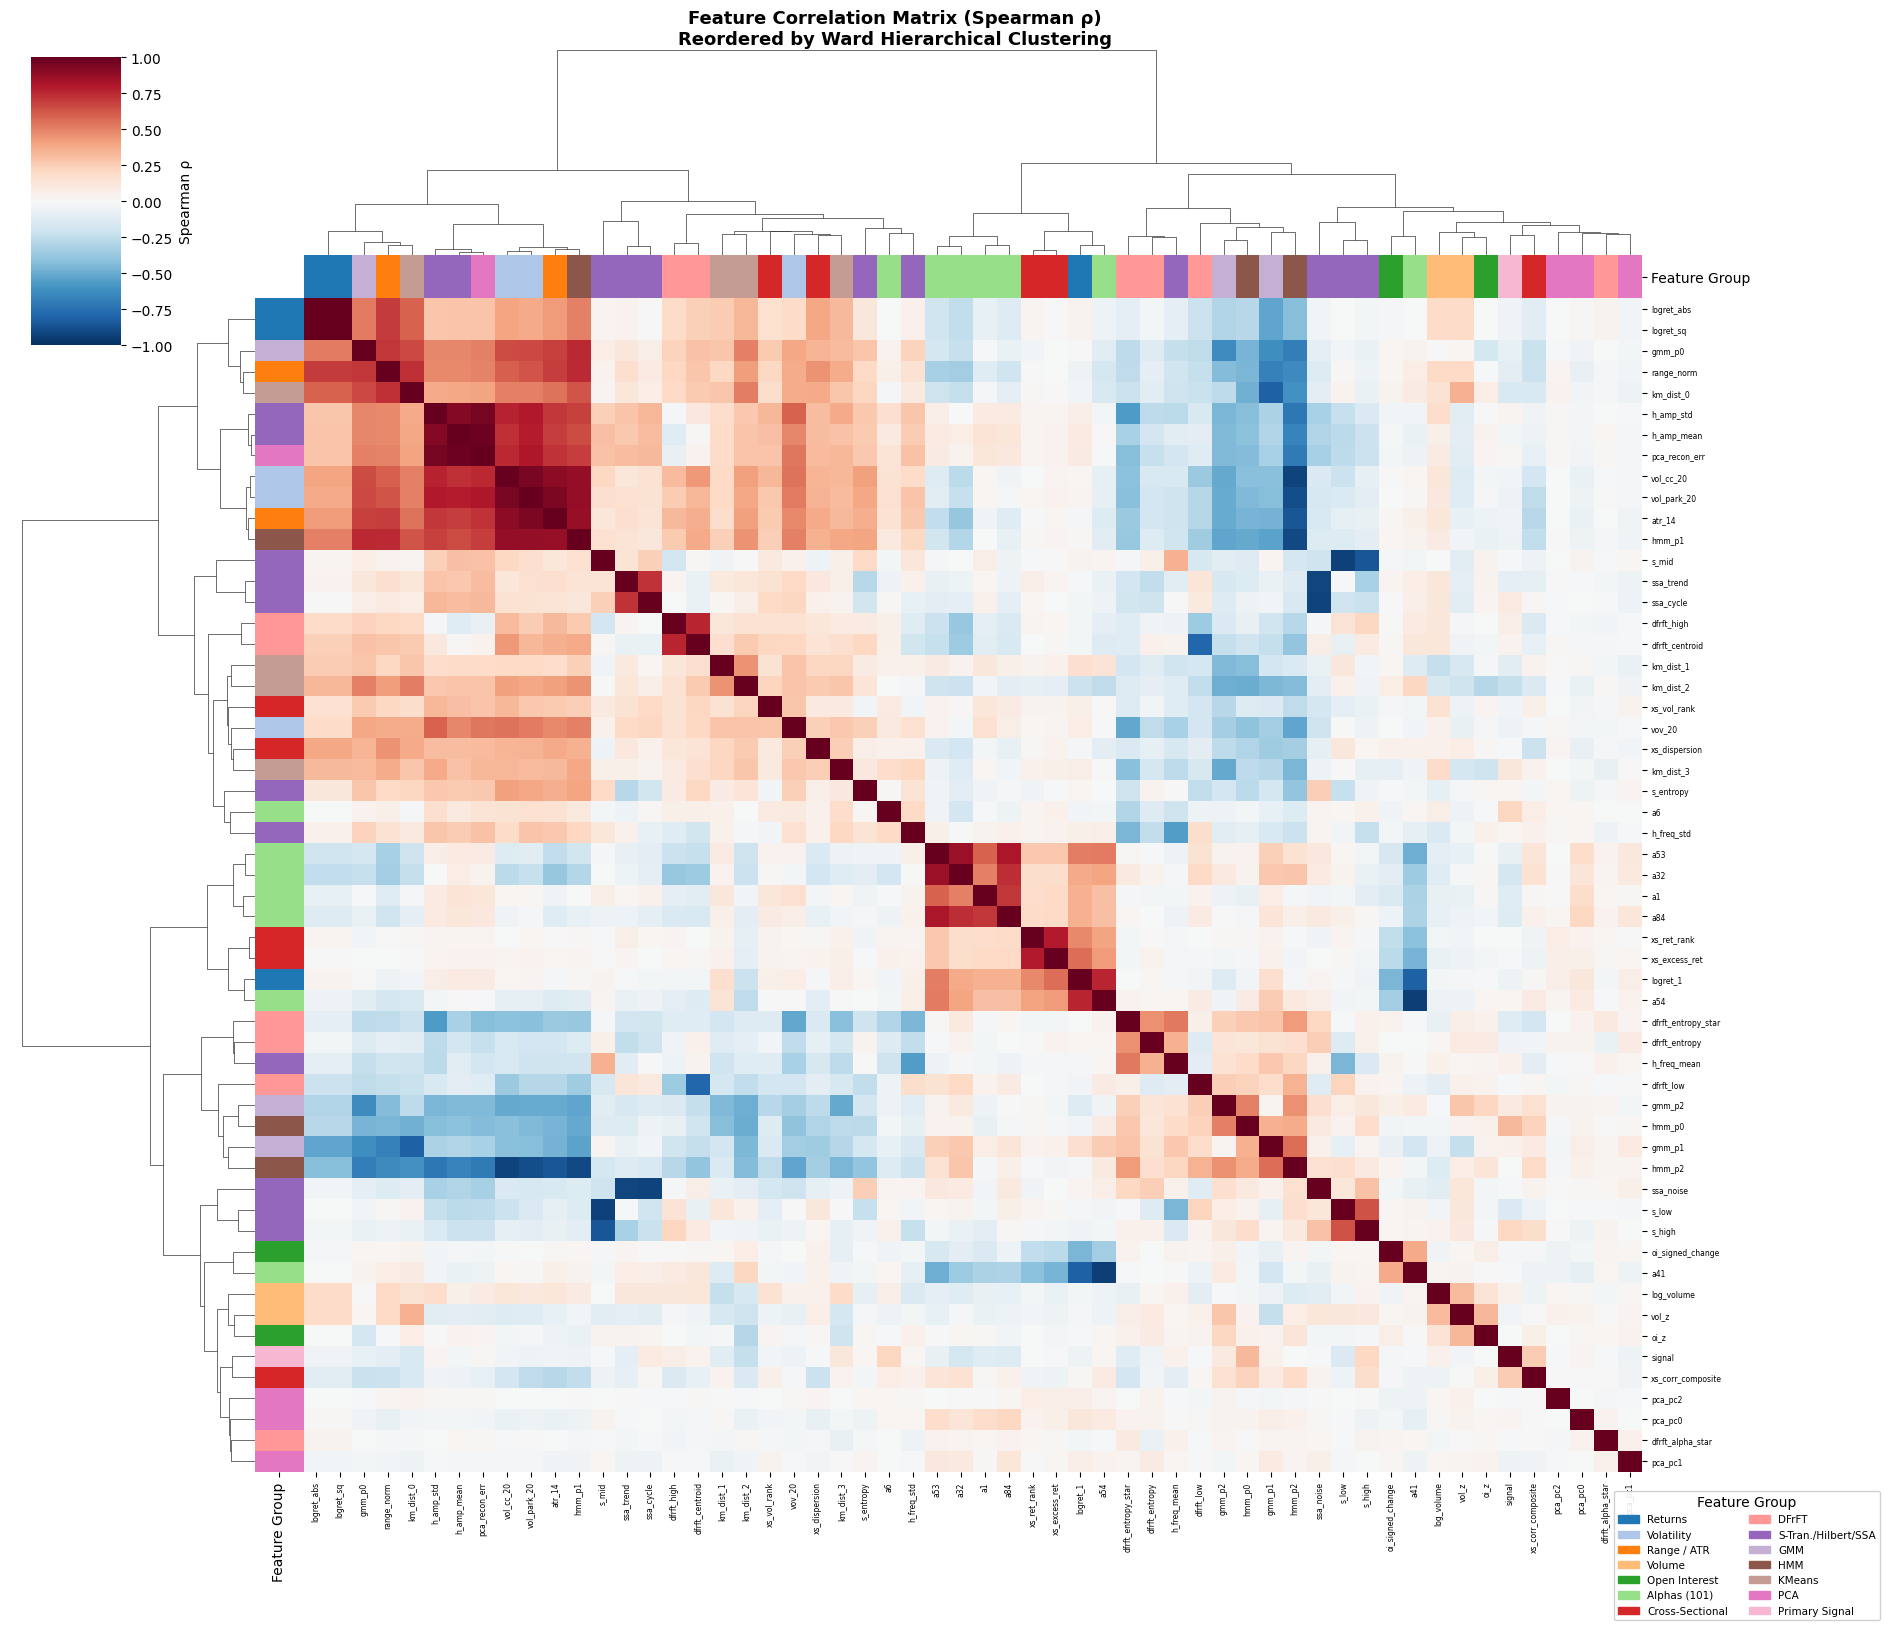

Saved: feature_correlation_clustermap.png

Data-driven cluster sizes  (K = 14, matching number of manual groups):
  Cluster  1  ( 4 feats)  dominant manual group: Alphas (101)
  Cluster  2  ( 6 feats)  dominant manual group: Alphas (101)
  Cluster  3  ( 9 feats)  dominant manual group: S-Tran./Hilbert/SSA
  Cluster  4  ( 7 feats)  dominant manual group: Returns
  Cluster  5  ( 6 feats)  dominant manual group: KMeans
  Cluster  6  ( 3 feats)  dominant manual group: S-Tran./Hilbert/SSA
  Cluster  7  ( 3 feats)  dominant manual group: S-Tran./Hilbert/SSA
  Cluster  8  ( 5 feats)  dominant manual group: DFrFT
  Cluster  9  ( 3 feats)  dominant manual group: DFrFT
  Cluster 10  ( 3 feats)  dominant manual group: Volume
  Cluster 11  ( 3 feats)  dominant manual group: Primary Signal
  Cluster 12  ( 2 feats)  dominant manual group: DFrFT
  Cluster 13  ( 1 feats)  dominant manual group: PCA
  Cluster 14  ( 1 feats)  dominant manual group: PCA


In [40]:

# Impute training data with median before computing correlations
_imp  = _Imputer(strategy="median")
X_imp = pd.DataFrame(
    _imp.fit_transform(train_df[feature_cols]),
    columns=feature_cols,
)

# Spearman rank correlation — robust to outliers and non-linearities
corr_mat = X_imp.corr(method="spearman")

# Row/column colour annotations (one colour per manual group)
row_colors_series = pd.Series(
    {f: group_color_map[feat_to_group[f]]
     for f in feature_cols if f in feat_to_group},
    name="Feature Group",
)

# ── Clustermap: hierarchical ordering + heatmap ──────────────────────────────
cg = sns.clustermap(
    corr_mat,
    method="ward",          # Ward linkage minimises within-cluster variance
    figsize=(18, 16),
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    row_colors=row_colors_series,
    col_colors=row_colors_series,
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.15,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.4},
    linewidths=0,
)
cg.ax_heatmap.set_xticklabels(
    cg.ax_heatmap.get_xticklabels(), fontsize=5.5, rotation=90)
cg.ax_heatmap.set_yticklabels(
    cg.ax_heatmap.get_yticklabels(), fontsize=5.5, rotation=0)
cg.fig.suptitle(
    "Feature Correlation Matrix (Spearman ρ)\n"
    "Reordered by Ward Hierarchical Clustering",
    y=1.01, fontsize=13, fontweight="bold",
)

# Add feature-group colour legend
legend_handles = [
    mpatches.Patch(color=group_color_map[g], label=g)
    for g in group_names if g in group_color_map
]
cg.fig.legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(1.05, 0.0),
    fontsize=7.5,
    ncol=2,
    title="Feature Group",
    framealpha=0.9,
)
plt.savefig("feature_correlation_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_correlation_clustermap.png")

# ── Compare data-driven clusters against manual groups ───────────────────────
dist_mat       = 1 - corr_mat.abs()
dist_mat_arr   = dist_mat.values.copy()
np.fill_diagonal(dist_mat_arr, 0)
condensed_dist = squareform(np.clip(dist_mat_arr, 0, None), checks=False)
Z_linkage      = linkage(condensed_dist, method="ward")

K               = len(present_groups)
dd_labels       = fcluster(Z_linkage, t=K, criterion="maxclust")

print(f"\nData-driven cluster sizes  (K = {K}, matching number of manual groups):")
for c in sorted(set(dd_labels)):
    members       = [f for f, lbl in zip(feature_cols, dd_labels) if lbl == c]
    dominant      = (pd.Series([feat_to_group.get(f, "?") for f in members])
                     .value_counts().index[0])
    print(f"  Cluster {c:2d}  ({len(members):2d} feats)  dominant manual group: {dominant}")


## Step 2 — MDI (Mean Decrease Impurity) at Cluster Level

Aggregate the Random Forest's node-impurity-based feature importances to the cluster
level.  MDI is fast and in-sample, but is known to be biased toward high-cardinality
or highly correlated features, so it should be cross-validated against MDA and SHAP.

MDI at cluster level (Random Forest):
  S-Tran./Hilbert/SSA                : 0.4134  ██████████████████████████████
  Alphas (101)                       : 0.0886  ██████
  DFrFT                              : 0.0882  ██████
  PCA                                : 0.0751  █████
  Volatility                         : 0.0704  █████
  KMeans                             : 0.0555  ████
  Cross-Sectional                    : 0.0538  ███
  Open Interest                      : 0.0364  ██
  HMM                                : 0.0359  ██
  Range / ATR                        : 0.0224  █
  GMM                                : 0.0192  █
  Volume                             : 0.0178  █
  Returns                            : 0.0173  █
  Primary Signal                     : 0.0053  


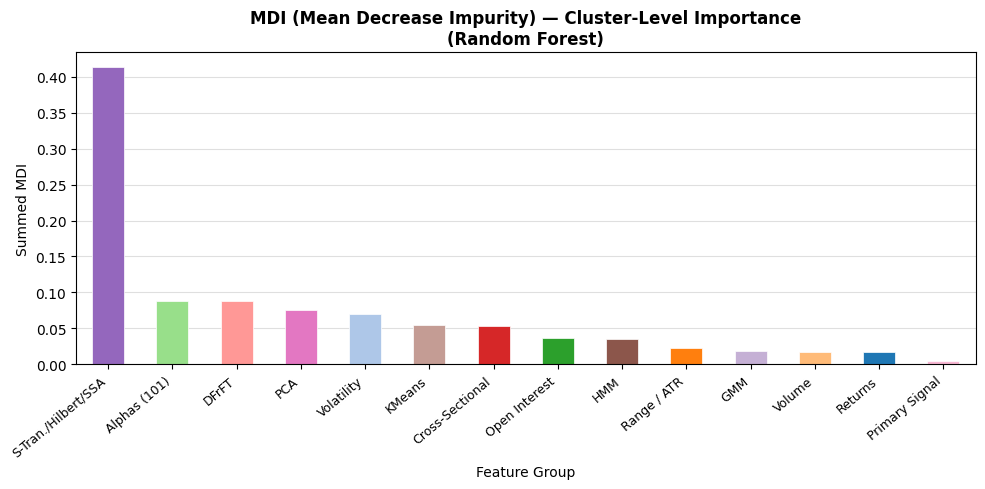

Saved: mdi_cluster_importance.png


In [41]:

# Extract fitted Random Forest and its preprocessing step
rf_fitted = rf_model.named_steps["model"]
rf_prep   = rf_model.named_steps["prep"]

# Reconstruct column names after ColumnTransformer preprocessing
_rf_ohe      = rf_prep.named_transformers_["cat"]
_rf_ohe_cols = list(_rf_ohe.get_feature_names_out(categorical_cols))
rf_all_cols  = feature_cols + _rf_ohe_cols   # same order as RF input

mdi_per_feat = pd.Series(rf_fitted.feature_importances_, index=rf_all_cols)

# Aggregate MDI: sum over all features belonging to each cluster
mdi_by_cluster = {}
for group, feats in present_groups.items():
    in_rf = [f for f in feats if f in mdi_per_feat.index]
    mdi_by_cluster[group] = float(mdi_per_feat[in_rf].sum()) if in_rf else 0.0

mdi_series = pd.Series(mdi_by_cluster).sort_values(ascending=False)

print("MDI at cluster level (Random Forest):")
for g, v in mdi_series.items():
    bar = "█" * int(v / mdi_series.max() * 30)
    print(f"  {g:<35s}: {v:.4f}  {bar}")

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = [group_color_map.get(g, "steelblue") for g in mdi_series.index]
mdi_series.plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title(
    "MDI (Mean Decrease Impurity) — Cluster-Level Importance\n(Random Forest)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Feature Group", fontsize=10)
ax.set_ylabel("Summed MDI", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("mdi_cluster_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mdi_cluster_importance.png")


## Step 3 — MDA (Mean Decrease Accuracy) at Cluster Level

For each cluster, **simultaneously permute all features in that cluster** across
observations, then record the drop in AUC on a chronological hold-out slice.
Permuting the entire cluster at once preserves the within-cluster correlation
structure while breaking only the cluster's predictive signal — this avoids the
double-counting bias that occurs when correlated features are permuted individually.

Baseline AUC on permutation set : 0.9276  (n = 191)
Number of permutation repeats   : 10

  Returns                            : ΔAUC = +0.0048  (std = 0.0013)
  Volatility                         : ΔAUC = +0.0515  (std = 0.0134)
  Range / ATR                        : ΔAUC = +0.0034  (std = 0.0020)
  Volume                             : ΔAUC = +0.0078  (std = 0.0017)
  Open Interest                      : ΔAUC = +0.0141  (std = 0.0027)
  Alphas (101)                       : ΔAUC = +0.0616  (std = 0.0047)
  Cross-Sectional                    : ΔAUC = +0.0255  (std = 0.0048)
  DFrFT                              : ΔAUC = +0.0392  (std = 0.0055)
  S-Tran./Hilbert/SSA                : ΔAUC = +0.1843  (std = 0.0256)
  GMM                                : ΔAUC = +0.0080  (std = 0.0018)
  HMM                                : ΔAUC = +0.0079  (std = 0.0044)
  KMeans                             : ΔAUC = +0.0242  (std = 0.0038)
  PCA                                : ΔAUC = +0.0793  (std = 0.0145)


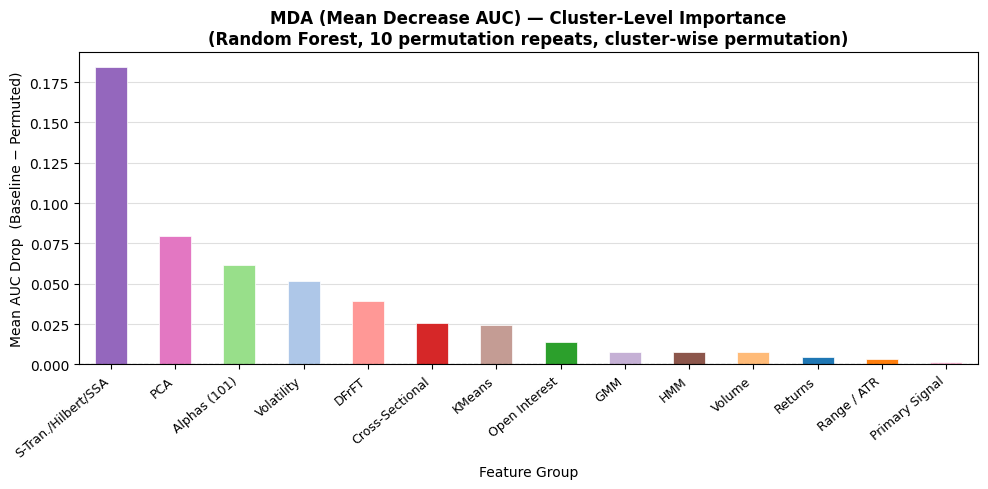

Saved: mda_cluster_importance.png


In [42]:

N_REPEATS = 10
rng_mda   = np.random.RandomState(RANDOM_STATE)

# Chronological hold-out: last 20 % of training data (never seen by the RF during CV)
val_idx = int(len(train_df) * 0.80)
perm_df = train_df.iloc[val_idx:].copy()
X_perm  = perm_df[feature_cols + categorical_cols].copy()
y_perm  = perm_df["label_binary"].astype(int).values

baseline_auc = roc_auc_score(y_perm, rf_model.predict_proba(X_perm)[:, 1])
print(f"Baseline AUC on permutation set : {baseline_auc:.4f}  (n = {len(y_perm)})")
print(f"Number of permutation repeats   : {N_REPEATS}\n")

mda_by_cluster = {}
for group, feats in present_groups.items():
    cluster_feats = [f for f in feats if f in feature_cols]
    if not cluster_feats:
        mda_by_cluster[group] = 0.0
        continue
    auc_drops = []
    for _ in range(N_REPEATS):
        X_copy   = X_perm.copy()
        perm_idx = rng_mda.permutation(len(X_copy))
        # Permute all cluster features together (same row-shuffle for all columns)
        X_copy[cluster_feats] = X_copy[cluster_feats].values[perm_idx]
        auc_drops.append(
            baseline_auc - roc_auc_score(y_perm, rf_model.predict_proba(X_copy)[:, 1])
        )
    mda_by_cluster[group] = float(np.mean(auc_drops))
    print(f"  {group:<35s}: ΔAUC = {mda_by_cluster[group]:+.4f}"
          f"  (std = {np.std(auc_drops):.4f})")

mda_series = pd.Series(mda_by_cluster).sort_values(ascending=False)

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [
    "tomato" if v < 0 else group_color_map.get(g, "steelblue")
    for g, v in mda_series.items()
]
mda_series.plot(kind="bar", ax=ax, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(
    f"MDA (Mean Decrease AUC) — Cluster-Level Importance\n"
    f"(Random Forest, {N_REPEATS} permutation repeats, cluster-wise permutation)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Feature Group", fontsize=10)
ax.set_ylabel("Mean AUC Drop  (Baseline − Permuted)", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("mda_cluster_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mda_cluster_importance.png")


## Step 4 — SHAP at Cluster Level

TreeExplainer computes exact Shapley values for tree-based models.  We use the
XGBoost model when available, otherwise fall back to Random Forest.  The mean
absolute SHAP value per feature is summed within each cluster to give a
cluster-level attribution score.  A beeswarm plot then shows the direction and
magnitude of the top individual features.

Computing SHAP values  (Random Forest, n = 952) ...

SHAP at cluster level (Random Forest):
  S-Tran./Hilbert/SSA                : 0.1442  ██████████████████████████████
  PCA                                : 0.0477  █████████
  DFrFT                              : 0.0288  █████
  Cross-Sectional                    : 0.0243  █████
  Volatility                         : 0.0225  ████
  Alphas (101)                       : 0.0212  ████
  KMeans                             : 0.0155  ███
  HMM                                : 0.0141  ██
  Open Interest                      : 0.0087  █
  Range / ATR                        : 0.0077  █
  GMM                                : 0.0063  █
  Volume                             : 0.0056  █
  Primary Signal                     : 0.0030  
  Returns                            : 0.0028  


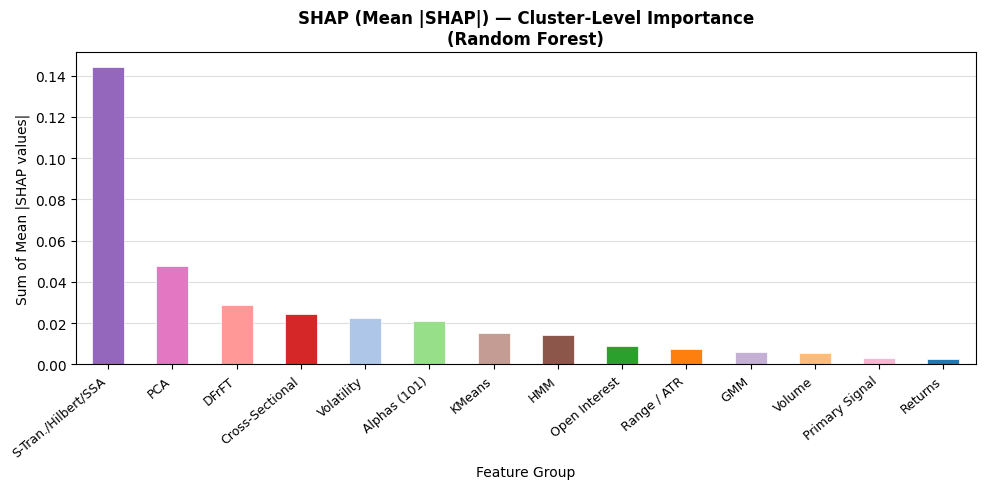

Saved: shap_cluster_importance.png


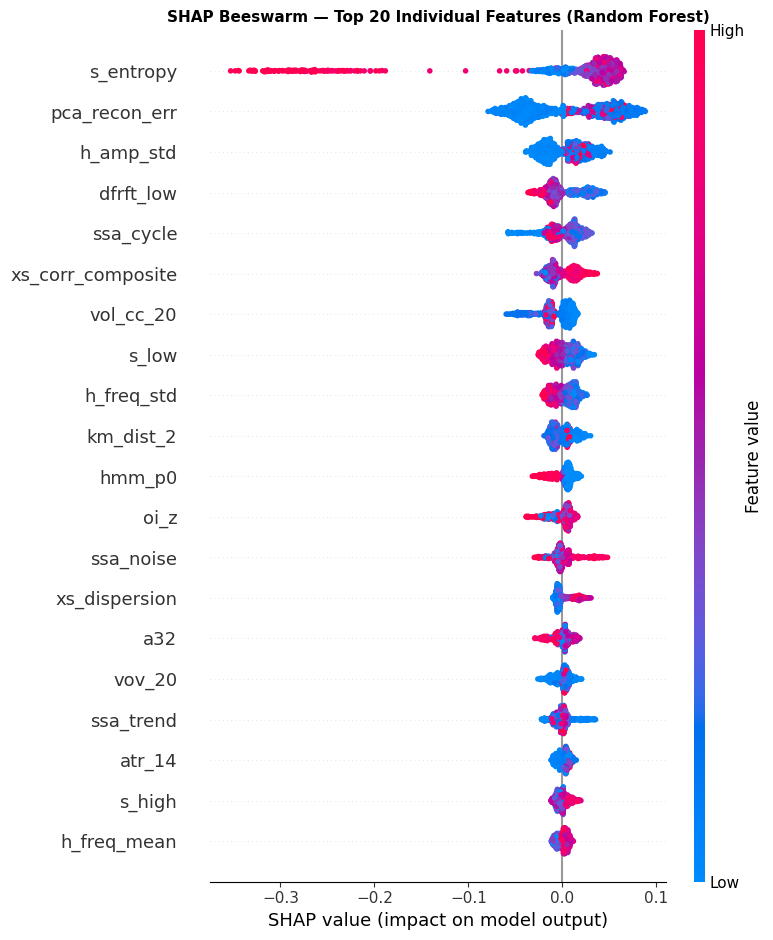

Saved: shap_beeswarm_top_features.png


In [43]:

if not SHAP_AVAILABLE:
    print("SHAP not available; skipping this cell.")
    shap_series     = None
    shap_model_name = "N/A"
else:
    # Use XGBoost when available, otherwise fall back to Random Forest
    shap_model_name = (
        "XGBoost"
        if (XGBOOST_AVAILABLE and xgb_model is not None)
        else "Random Forest"
    )
    chosen_pipe = (
        xgb_model
        if (XGBOOST_AVAILABLE and xgb_model is not None)
        else rf_model
    )

    shap_prep = chosen_pipe.named_steps["prep"]
    shap_mdl  = chosen_pipe.named_steps["model"]

    # Reconstruct output column names from the ColumnTransformer
    _s_ohe      = shap_prep.named_transformers_["cat"]
    _s_ohe_cols = list(_s_ohe.get_feature_names_out(categorical_cols))
    shap_col_names = feature_cols + _s_ohe_cols   # numerical cols first, then OHE

    # Transform the full training set
    X_shap_full = shap_prep.transform(train_df[feature_cols + categorical_cols])

    # Subsample (≤ 1 000 rows) for tractable computation
    n_shap   = min(1000, X_shap_full.shape[0])
    rng_shap = np.random.RandomState(RANDOM_STATE)
    idx_shap = rng_shap.choice(X_shap_full.shape[0], size=n_shap, replace=False)
    X_shap_s = X_shap_full[idx_shap]

    print(f"Computing SHAP values  ({shap_model_name}, n = {n_shap}) ...")
    explainer   = shap.TreeExplainer(shap_mdl)
    shap_values = explainer.shap_values(X_shap_s)

    # Normalise different SHAP return formats to a single (n_samples, n_features) array
    if isinstance(shap_values, list):
        shap_arr = shap_values[1]        # list[class0, class1] → take positive class
    elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
        shap_arr = shap_values[:, :, 1]  # (n, features, classes) format
    else:
        shap_arr = shap_values

    # Mean |SHAP| per feature
    mean_abs_shap = np.abs(shap_arr).mean(axis=0)
    shap_feat_s   = pd.Series(mean_abs_shap, index=shap_col_names)

    # Aggregate to cluster level (sum over members)
    shap_by_cluster = {}
    for group, feats in present_groups.items():
        in_model = [f for f in feats if f in shap_feat_s.index]
        shap_by_cluster[group] = float(shap_feat_s[in_model].sum()) if in_model else 0.0

    shap_series = pd.Series(shap_by_cluster).sort_values(ascending=False)

    print(f"\nSHAP at cluster level ({shap_model_name}):")
    for g, v in shap_series.items():
        bar = "█" * int(v / shap_series.max() * 30)
        print(f"  {g:<35s}: {v:.4f}  {bar}")

    # ── Cluster-level bar chart ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    s_colors = [group_color_map.get(g, "steelblue") for g in shap_series.index]
    shap_series.plot(kind="bar", ax=ax, color=s_colors, edgecolor="white", linewidth=0.5)
    ax.set_title(
        f"SHAP (Mean |SHAP|) — Cluster-Level Importance\n({shap_model_name})",
        fontsize=12, fontweight="bold",
    )
    ax.set_xlabel("Feature Group", fontsize=10)
    ax.set_ylabel("Sum of Mean |SHAP values|", fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig("shap_cluster_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: shap_cluster_importance.png")

    # ── Beeswarm: top individual features (numerical only, excludes OHE cols) ─
    n_num_feats = len(feature_cols)
    shap_num    = shap_arr[:, :n_num_feats]
    data_num    = X_shap_s[:, :n_num_feats]

    top_n     = 20
    top_order = np.argsort(np.abs(shap_num).mean(axis=0))[::-1][:top_n]
    top_names = [feature_cols[i] for i in top_order]

    shap.summary_plot(
        shap_num[:, top_order],
        features=data_num[:, top_order],
        feature_names=top_names,
        plot_type="dot",
        max_display=top_n,
        show=False,
    )
    plt.title(
        f"SHAP Beeswarm — Top {top_n} Individual Features ({shap_model_name})",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig("shap_beeswarm_top_features.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: shap_beeswarm_top_features.png")


## Step 5 — Combined Comparison and Discussion

Normalise all three importance vectors to sum to 1 for fair comparison, then
visualise them side-by-side as a grouped bar chart and a heatmap.

Normalised cluster-level importance (fraction of total):
                     MDI (RF)  MDA (RF)  SHAP (Random Forest)
S-Tran./Hilbert/SSA     0.414     0.359                 0.409
PCA                     0.075     0.155                 0.135
Alphas (101)            0.089     0.120                 0.060
DFrFT                   0.088     0.076                 0.082
Volatility              0.070     0.100                 0.064
Cross-Sectional         0.054     0.050                 0.069
KMeans                  0.055     0.047                 0.044
HMM                     0.036     0.015                 0.040
Open Interest           0.036     0.027                 0.025
GMM                     0.019     0.016                 0.018
Range / ATR             0.022     0.007                 0.022
Volume                  0.018     0.015                 0.016
Returns                 0.017     0.009                 0.008
Primary Signal          0.005     0.003                 0.009


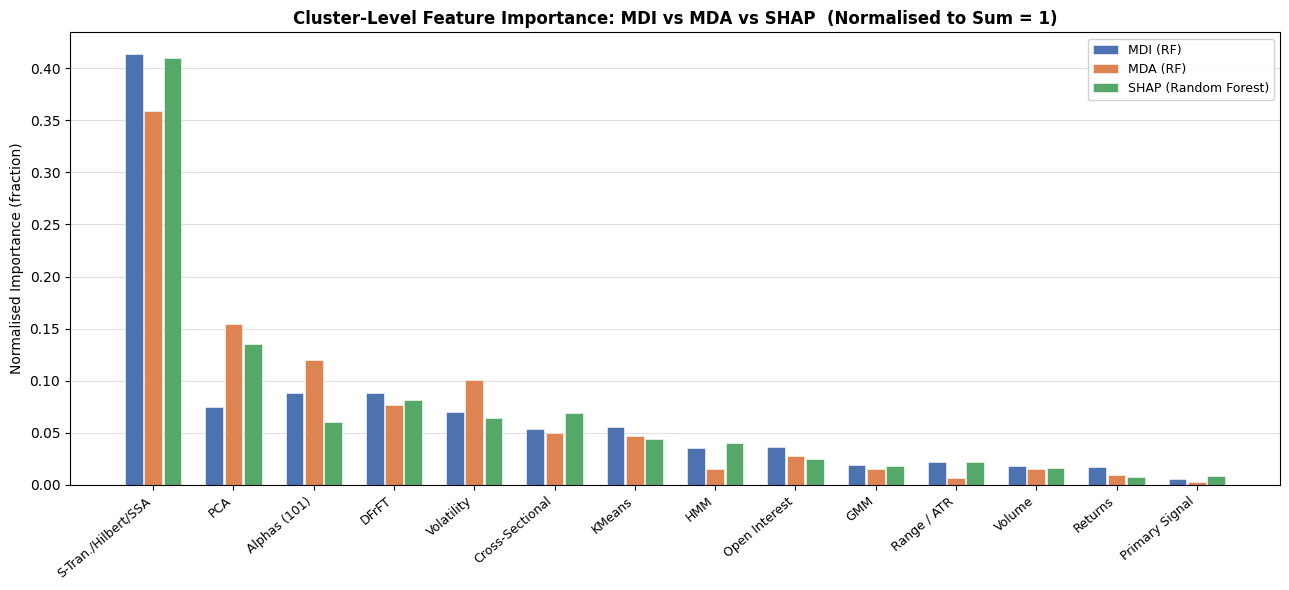

Saved: cluster_importance_comparison.png


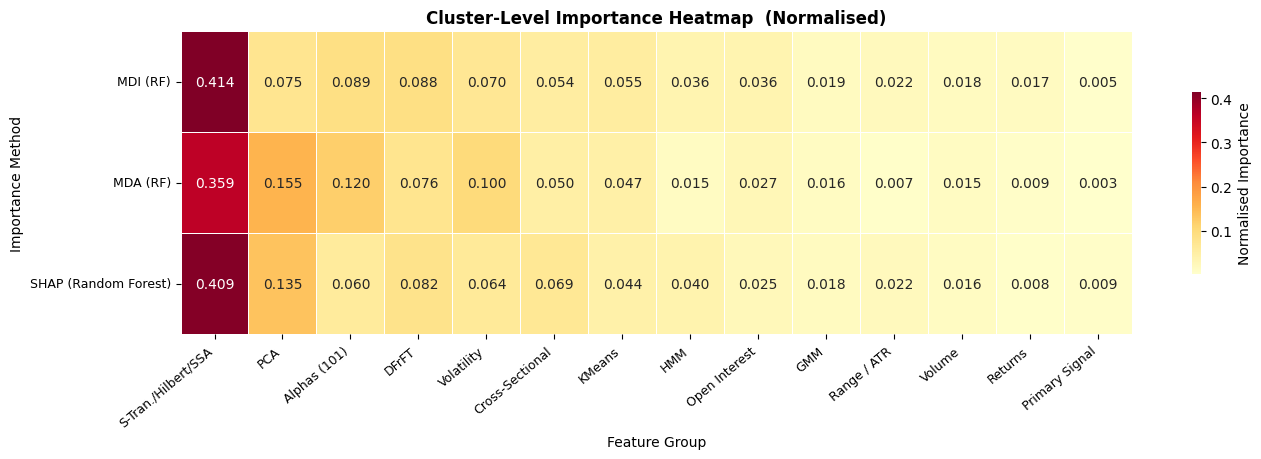

Saved: cluster_importance_heatmap.png


In [44]:

def _normalise(s):
    """Clip negative values to zero, then normalise so the vector sums to 1."""
    s_pos = s.clip(lower=0)
    total = s_pos.sum()
    return s_pos / total if total > 0 else s_pos


all_groups   = list(present_groups.keys())
mdi_norm     = _normalise(mdi_series.reindex(all_groups, fill_value=0))
mda_norm     = _normalise(mda_series.reindex(all_groups, fill_value=0))

comparison_dict = {"MDI (RF)": mdi_norm, "MDA (RF)": mda_norm}
if SHAP_AVAILABLE and shap_series is not None:
    comparison_dict[f"SHAP ({shap_model_name})"] = \
        _normalise(shap_series.reindex(all_groups, fill_value=0))

comparison_df = pd.DataFrame(comparison_dict).fillna(0)
# Sort clusters by average importance across all methods
comparison_df["avg"] = comparison_df.mean(axis=1)
comparison_df = comparison_df.sort_values("avg", ascending=False).drop(columns="avg")

print("Normalised cluster-level importance (fraction of total):")
print(comparison_df.round(3).to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
x         = np.arange(len(comparison_df))
n_methods = len(comparison_df.columns)
width     = 0.72 / n_methods
palette   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, col in enumerate(comparison_df.columns):
    offset = (i - n_methods / 2 + 0.5) * width
    ax.bar(
        x + offset,
        comparison_df[col].values,
        width=width * 0.92,
        label=col,
        color=palette[i % len(palette)],
        edgecolor="white",
        linewidth=0.4,
    )

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Normalised Importance (fraction)", fontsize=10)
ax.set_title(
    "Cluster-Level Feature Importance: MDI vs MDA vs SHAP  (Normalised to Sum = 1)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9, framealpha=0.9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("cluster_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_importance_comparison.png")

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(len(comparison_df) * 0.85 + 2,
                                len(comparison_dict) * 0.9 + 2))
sns.heatmap(
    comparison_df.T,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Normalised Importance", "shrink": 0.6},
    ax=ax,
)
ax.set_title(
    "Cluster-Level Importance Heatmap  (Normalised)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Feature Group", fontsize=10)
ax.set_ylabel("Importance Method", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("cluster_importance_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_importance_heatmap.png")


## Discussion: Which Feature Groups Drive the Metamodel?

### Interpretation of the Correlation Structure

Ward hierarchical clustering of the Spearman correlation matrix reveals that the
data-driven grouping (K = 14) only **partially** aligns with the manual feature groups.
Notably, S-Transform/Hilbert/SSA features split across **three separate data-driven
clusters** (clusters 3, 6 and 7), and DFrFT features similarly split into three
clusters (clusters 8, 9 and 12), indicating internal substructure within these
engineered groups.  By contrast, Volume features (cluster 10) and Primary Signal
features (cluster 11) each form tight, self-contained clusters, confirming that those
groups share a common source of variation.

High intra-group correlations within compositional features (GMM/HMM probabilities
sum to 1; DFrFT sub-band energies sum to 1) make per-feature rankings unstable.
Computing importance at the cluster level aggregates these shares into a single stable
score, which is the principal motivation for this analysis.

### Comparing MDI, MDA, and SHAP

| Feature Group | MDI (RF) | MDA (RF) | SHAP (RF) | Agreement |
|---|---|---|---|---|
| **S-Tran./Hilbert/SSA** | **41.4 %** | **35.9 %** | **40.9 %** | ✓ Strong |
| PCA | 7.5 % | **15.5 %** | **13.5 %** | MDA/SHAP > MDI |
| Alphas (101) | 8.9 % | 12.0 % | 6.0 % | Moderate |
| DFrFT | 8.8 % | 7.6 % | 8.2 % | ✓ Consistent |
| Volatility | 7.0 % | 10.0 % | 6.4 % | Moderate |
| Cross-Sectional | 5.4 % | 5.0 % | 6.9 % | ✓ Consistent |
| KMeans | 5.6 % | 4.7 % | 4.4 % | ✓ Consistent |
| HMM | 3.6 % | 1.5 % | 4.0 % | MDI > MDA |
| Open Interest | 3.6 % | 2.7 % | 2.5 % | Moderate |
| Range / ATR | 2.2 % | 0.7 % | 2.2 % | MDI > MDA |
| GMM | 1.9 % | 1.6 % | 1.8 % | ✓ Consistent |
| Volume | 1.8 % | 1.5 % | 1.6 % | ✓ Consistent |
| Returns | 1.7 % | 0.9 % | 0.8 % | MDI > MDA |
| **Primary Signal** | 0.5 % | 0.3 % | 0.9 % | ✓ Negligible |

Groups where **MDI > MDA** (HMM, Range/ATR, Returns) are likely inflated by in-sample
correlations; MDI rewards features that frequently appear at internal tree splits,
which can occur simply because a feature is correlated with other informative features.
Groups where **MDA > MDI** (PCA, Alphas, Volatility) are underweighted by MDI, most
probably because their principal components or aggregate alphas suppress per-feature
split frequency despite high out-of-sample predictive value.

### Key Findings

- **S-Transform / Hilbert / SSA features are the dominant driver** under all three
  methods (≈ 36–41 % of total importance), by a margin far exceeding any other group.
  These features decompose the log-return series into sub-band amplitudes, instantaneous
  frequency, and trend/cycle/noise components.  Their dominance suggests the metamodel
  primarily filters the primary signal by whether the current price action is in a
  *structured, cyclically coherent* regime versus a noisy one.

- **PCA features are strongly underestimated by MDI** (7.5 %) but emerge as the
  second-most important group under MDA (15.5 %) and SHAP (13.5 %).  Because PCA
  components are mutually orthogonal, they offer no redundancy with other features,
  so MDI's split-based counting undervalues them relative to correlated groups.  The
  high MDA score confirms that permuting PCA components jointly causes a large AUC
  drop, indicating genuine out-of-sample predictive content.

- **DFrFT features show the most reliable ranking** across all three methods (8.8 /
  7.6 / 8.2 %), placing them third.  The near-equality of MDI and MDA implies that
  DFrFT information is genuinely informative and not merely correlated with other
  high-MDI features.  Together, spectral features (DFrFT + S-Tran./Hilbert/SSA)
  account for roughly **49 % of importance** — a clear indication that
  time-frequency decomposition is the most useful transformation applied.

- **Alphas (101)** show moderate but consistent importance (MDI: 8.9 %, MDA: 12.0 %,
  SHAP: 6.0 %).  Their higher MDA relative to SHAP suggests they improve AUC when
  permuted jointly but that individual alpha contributions, as measured by SHAP, are
  more diffuse.  The diverse construction of the seven retained alphas (cross-corr,
  signed power, time-series rank, etc.) provides partial intra-group orthogonality.

- **Primary Signal** itself has the **lowest importance** of all 14 groups under every
  method (MDI: 0.5 %, MDA: 0.3 %, SHAP: 0.9 %).  This is a critical insight: the
  metamodel does not simply amplify the signal; it adds substantial incremental value
  through engineered features that are largely orthogonal to the raw signal.  The
  signal's direction enters the dataset implicitly through label construction
  (triple-barrier applied conditional on signal direction), so the model learns
  *when* the signal succeeds rather than *which* direction to trade.

- **Cross-Sectional features** contribute consistently (5–7 %) and are useful for
  identifying dispersion events across the energy complex, where instrument-specific
  divergence tends to make the primary signal less reliable.

- **Regime detection features (GMM, HMM, KMeans)** collectively account for roughly
  10–12 % but individually each group falls in the 2–6 % range.  HMM's MDI > MDA
  divergence suggests some in-sample overfit; GMM and KMeans are more consistent.

### Conclusion

The cluster-level analysis reveals that the metamodel derives its predictive power from
**two dominant information layers**: (1) **time-frequency decomposition** of price
dynamics (S-Transform, Hilbert, SSA, DFrFT — jointly ≈ 49 %), which captures whether
the market is in a structured, cyclically coherent state where the primary signal
tends to succeed; and (2) **compressed, orthogonal representations** of the feature
space (PCA ≈ 13–15 %) that remove redundancy and expose latent structure not visible
in any individual feature.  Volatility, cross-sectional context, and regime-detection
features form a third, supporting layer (≈ 20–25 % combined), while the raw primary
signal itself contributes less than 1 %, confirming that the metamodel's value lies
entirely in the engineered feature set.